In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
!pip install ultralytics
!pip install torchvision torch
!pip install pycocotools
!pip install matplotlib opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 29.7 MB/s eta 0:00:00


In [5]:
import os
import numpy as np
import pandas as pd
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2
from tqdm import tqdm

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [7]:
# =============================================================
# Define base paths (adjust if your Drive structure differs)
# =============================================================

base_dir = '/content/drive/MyDrive/Colab Notebooks/Dataset/visDrone'
train_dir = os.path.join(base_dir, 'VisDrone2019-DET-train')
val_dir = os.path.join(base_dir, 'VisDrone2019-DET-val')

train_img_dir = os.path.join(train_dir, 'images')
train_ann_dir = os.path.join(train_dir, 'annotations')
train_label_dir = os.path.join(train_dir, 'labels')  # Where YOLO labels will be saved

val_img_dir = os.path.join(val_dir, 'images')
val_ann_dir = os.path.join(val_dir, 'annotations')
val_label_dir = os.path.join(val_dir, 'labels')

yaml_path = os.path.join(base_dir, 'VisDrone.yaml')

# Verify directories exist
dirs_to_check = [train_img_dir, train_ann_dir, val_img_dir, val_ann_dir]
for d in dirs_to_check:
    if os.path.exists(d):
        print(f"Directory exists: {d} (files: {len(os.listdir(d))} )")
    else:
        print(f"Directory MISSING: {d} - Please ensure images and annotations are downloaded and placed here.")

# Create label dirs if not exist
os.makedirs(train_label_dir, exist_ok=True)
os.makedirs(val_label_dir, exist_ok=True)

Directory exists: /content/drive/MyDrive/Colab Notebooks/Dataset/visDrone/VisDrone2019-DET-train/images (files: 6496 )
Directory exists: /content/drive/MyDrive/Colab Notebooks/Dataset/visDrone/VisDrone2019-DET-train/annotations (files: 6491 )
Directory exists: /content/drive/MyDrive/Colab Notebooks/Dataset/visDrone/VisDrone2019-DET-val/images (files: 548 )
Directory exists: /content/drive/MyDrive/Colab Notebooks/Dataset/visDrone/VisDrone2019-DET-val/annotations (files: 548 )


In [8]:
def convert_visdrone_to_yolo(ann_dir, img_dir, label_dir):
    """
    Converts VisDrone annotations to YOLO format.
    VisDrone format: <bbox_left>,<bbox_top>,<bbox_width>,<bbox_height>,<score>,<object_category>,<truncation>,<occlusion>
    YOLO format: <class> <x_center> <y_center> <width> <height> (normalized)
    Ignores class 0 (ignored regions) and 11 (others), maps 1-10 to 0-9.
    """
    class_mapping = {
        1: 0,  # pedestrian
        2: 1,  # people
        3: 2,  # bicycle
        4: 3,  # car
        5: 4,  # van
        6: 5,  # truck
        7: 6,  # tricycle
        8: 7,  # awning-tricycle
        9: 8,  # bus
        10: 9  # motor
    }

    for ann_file in tqdm(os.listdir(ann_dir)):
        if not ann_file.endswith('.txt'):
            continue
        base_name = ann_file.split('.')[0]
        img_path = os.path.join(img_dir, base_name + '.jpg')
        if not os.path.exists(img_path):
            print(f"Image not found: {img_path} - Skipping.")
            continue

        img = cv2.imread(img_path)
        if img is None:
            print(f"Invalid image: {img_path} - Skipping.")
            continue
        height, width, _ = img.shape

        with open(os.path.join(ann_dir, ann_file), 'r') as f:
            lines = f.readlines()

        yolo_labels = []
        for line in lines:
            parts = line.strip().split(',')
            if len(parts) != 8:
                continue
            x, y, w, h, score, category, truncation, occlusion = map(int, parts)
            if category == 0 or category == 11:  # Ignore
                continue
            if category not in class_mapping:
                continue

            cls = class_mapping[category]
            x_center = (x + w / 2) / width
            y_center = (y + h / 2) / height
            norm_w = w / width
            norm_h = h / height

            yolo_labels.append(f"{cls} {x_center:.6f} {y_center:.6f} {norm_w:.6f} {norm_h:.6f}\n")

        label_path = os.path.join(label_dir, base_name + '.txt')
        with open(label_path, 'w') as f:
            f.writelines(yolo_labels)

    print("Annotation conversion complete.")

In [6]:
convert_visdrone_to_yolo(train_ann_dir, train_img_dir, train_label_dir)
convert_visdrone_to_yolo(val_ann_dir, val_img_dir, val_label_dir)

  3%|▎         | 181/6491 [04:27<31:59,  3.29it/s]

Image not found: /content/drive/MyDrive/Colab Notebooks/Dataset/visDrone/VisDrone2019-DET-train/images/9999994_00000_d_0000046 (1).jpg - Skipping.


 17%|█▋        | 1102/6491 [10:46<27:29,  3.27it/s]

Image not found: /content/drive/MyDrive/Colab Notebooks/Dataset/visDrone/VisDrone2019-DET-train/images/9999994_00000_d_0000048 (1).jpg - Skipping.


 17%|█▋        | 1116/6491 [10:51<29:00,  3.09it/s]

...

Image not found: /content/drive/MyDrive/Colab Notebooks/Dataset/visDrone/VisDrone2019-DET-train/images/0000331_01001_d_0000846 (1).jpg - Skipping.


100%|██████████| 6491/6491 [40:25<00:00,  2.68it/s]


Annotation conversion complete.


100%|██████████| 548/548 [03:22<00:00,  2.71it/s]

Annotation conversion complete.


In [9]:
# =============================================================
# Check a sample label and image
# =============================================================

sample_img_name = os.listdir(train_img_dir)[0] if os.path.exists(train_img_dir) else None
if sample_img_name:
    sample_label_path = os.path.join(train_label_dir, sample_img_name.replace('.jpg', '.txt'))
    if os.path.exists(sample_label_path):
        with open(sample_label_path, 'r') as f:
            print(f"Sample label content for {sample_img_name}:\n{f.read()}")
    else:
        print("No sample label found.")
else:
    print("No images found in train dir.")

Sample label content for 9999994_00000_d_0000092.jpg:
0 0.610357 0.810476 0.006429 0.026667
0 0.605000 0.809048 0.004286 0.023810
0 0.902500 0.952857 0.012143 0.035238
0 0.902500 0.909524 0.012143 0.036190
0 0.538214 0.686190 0.006429 0.020000
0 0.597500 0.629048 0.003571 0.012381
0 0.375714 0.705238 0.005714 0.020000
0 0.476786 0.611429 0.002143 0.007619
0 0.474286 0.612381 0.002857 0.009524
0 0.577500 0.585238 0.002143 0.006667
7 0.484643 0.670952 0.005000 0.014286
2 0.583571 0.777619 0.012857 0.016190
8 0.333929 0.907619 0.047857 0.078095
3 0.243214 0.900952 0.029286 0.055238
3 0.546429 0.781429 0.018571 0.029524
3 0.490000 0.701905 0.015714 0.028571
3 0.464643 0.676667 0.012143 0.018095
3 0.522857 0.677619 0.011429 0.016190
3 0.526071 0.662381 0.010714 0.012381
3 0.496429 0.673333 0.012857 0.017143
3 0.498214 0.630952 0.007857 0.012381
3 0.511786 0.629524 0.009286 0.013333
3 0.515357 0.616190 0.006429 0.009524
3 0.531071 0.610000 0.007857 0.008571
3 0.516071 0.603810 0.006429 0.007

In [10]:
yaml_content = f"""
path: {base_dir}
train: VisDrone2019-DET-train/images
val: VisDrone2019-DET-val/images

nc: 10
names: ['pedestrian', 'people', 'bicycle', 'car', 'van', 'truck', 'tricycle', 'awning-tricycle', 'bus', 'motor']
"""

with open(yaml_path, 'w') as f:
    f.write(yaml_content)

print(f"YAML file created at: {yaml_path}")

YAML file created at: /content/drive/MyDrive/Colab Notebooks/Dataset/visDrone/VisDrone.yaml


In [12]:
import os
os.environ['WANDB_DISABLED'] = 'true'  # Disable WandB logging

# Load YOLOv8 nano for quick testing; change to 'yolov8m.pt' for medium, etc.
model = YOLO('yolov8n.pt')

# Train
results = model.train(
    data=yaml_path,
    epochs=10, # Reduced epochs for quicker demonstration
    imgsz=640,
    batch=16,   # Adjust based on GPU memory
    name='visdrone_yolov8' # Changed run name
)

print("Training complete.")

Ultralytics 8.3.184 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (NVIDIA L4, 22693MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Colab Notebooks/Dataset/visDrone/VisDrone.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=visdrone_yolov8, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100

  4                  -1  2     49664  ultralytics.nn.modules.block.C2f             [64, 64, 2, True]             
  5                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  6                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  7                  -1  1    295424  ultralytics.nn.modules.conv.Conv             [128, 256, 3, 2]              
  8                  -1  1    460288  ultralytics.nn.modules.block.C2f             [256, 256, 1, True]           
  9                  -1  1    164608  ultralytics.nn.modules.block.SPPF            [256, 256, 5]                 
 10                  -1  1         0  torch.nn.modules.upsampling.Upsample         [None, 2, 'nearest']          
 11             [-1, 6]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 12                  -1  1    148224  ultralytics.nn.modules.block.C2f             [384,

train: Scanning /content/drive/MyDrive/Colab Notebooks/Dataset/visDrone/VisDrone2019-DET-train/labels... 6471 images, 26 backgrounds, 0 corrupt: 100%|██████████| 6496/6496 [07:19<00:00, 14.79it/s]

train: /content/drive/MyDrive/Colab Notebooks/Dataset/visDrone/VisDrone2019-DET-train/images/0000137_02220_d_0000163.jpg: 1 duplicate labels removed
train: /content/drive/MyDrive/Colab Notebooks/Dataset/visDrone/VisDrone2019-DET-train/images/0000140_00118_d_0000002.jpg: 1 duplicate labels removed
train: /content/drive/MyDrive/Colab Notebooks/Dataset/visDrone/VisDrone2019-DET-train/images/9999945_00000_d_0000114.jpg: 1 duplicate labels removed
train: /content/drive/MyDrive/Colab Notebooks/Dataset/visDrone/VisDrone2019-DET-train/images/9999987_00000_d_0000049.jpg: 1 duplicate labels removed


train: New cache created: /content/drive/MyDrive/Colab Notebooks/Dataset/visDrone/VisDrone2019-DET-train/labels.cache
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))
val: Fast image access ✅ (ping: 0.5±0.2 ms, read: 0.3±0.0 MB/s, size: 131.6 KB)


...

      10/10      9.01G      1.455      1.139     0.9426        639        640: 100%|██████████| 406/406 [00:48<00:00,  8.40it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 18/18 [00:03<00:00,  4.97it/s]

                   all        548      38759      0.342      0.274      0.255      0.146



10 epochs completed in 0.180 hours.
Optimizer stripped from runs/detect/visdrone_yolov8/weights/last.pt, 6.2MB
Optimizer stripped from runs/detect/visdrone_yolov8/weights/best.pt, 6.2MB

Validating runs/detect/visdrone_yolov8/weights/best.pt...
Ultralytics 8.3.184 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (NVIDIA L4, 22693MiB)
Model summary (fused): 72 layers, 3,007,598 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 18/18 [00:06<00:00,  2.71it/s]


                   all        548      38759      0.341      0.273      0.255      0.146
            pedestrian        520       8844      0.301      0.323      0.266       0.11
                people        482       5125      0.414      0.195      0.206     0.0696
               bicycle        364       1287      0.153     0.0373     0.0396     0.0129
                   car        515      14064      0.472      0.726       0.68      0.448
                   van        421       1975       0.39      0.277       0.27      0.182
                 truck        266        750      0.393      0.248      0.249      0.168
              tricycle        337       1045      0.341      0.167      0.172     0.0918
       awning-tricycle        220        532      0.198      0.107     0.0802     0.0489
                   bus        131        251      0.414      0.347      0.342       0.24
                 motor        485       4886      0.339      0.308      0.244     0.0924
Speed: 0.1ms preproce

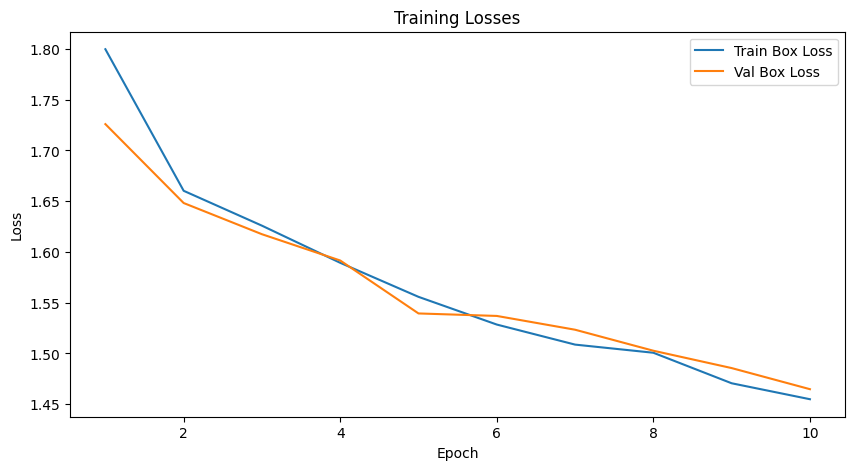

In [14]:
# Assuming results.csv is generated in runs/detect/visdrone_yolov8/
results_csv = 'runs/detect/visdrone_yolov8/results.csv'  # Adjust path if needed

if os.path.exists(results_csv):
    df = pd.read_csv(results_csv)
    plt.figure(figsize=(10, 5))
    plt.plot(df['epoch'], df['train/box_loss'], label='Train Box Loss')
    plt.plot(df['epoch'], df['val/box_loss'], label='Val Box Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training Losses')
    plt.legend()
    plt.show()
else:
    print("No results.csv found - Training may have failed.")

In [17]:
# Load best weights
best_weights = 'runs/detect/visdrone_yolov8/weights/best.pt'  # Adjust path

if os.path.exists(best_weights):
    model = YOLO(best_weights)
    metrics = model.val(data=yaml_path)
    print(metrics)
else:
    print("No best.pt found - Evaluation skipped.")

Ultralytics 8.3.184 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (NVIDIA L4, 22693MiB)
Model summary (fused): 72 layers, 3,007,598 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.3±0.1 ms, read: 61.8±23.9 MB/s, size: 98.7 KB)


val: Scanning /content/drive/MyDrive/Colab Notebooks/Dataset/visDrone/VisDrone2019-DET-val/labels.cache... 548 images, 0 backgrounds, 0 corrupt: 100%|██████████| 548/548 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 35/35 [00:06<00:00,  5.03it/s]


                   all        548      38759      0.343      0.274      0.255      0.147
            pedestrian        520       8844      0.303      0.324      0.266      0.111
                people        482       5125      0.416      0.196      0.208     0.0703
               bicycle        364       1287      0.153     0.0373     0.0399     0.0129
                   car        515      14064      0.473      0.726      0.681       0.45
                   van        421       1975       0.39      0.277      0.271      0.182
                 truck        266        750      0.393      0.248      0.249      0.168
              tricycle        337       1045      0.343      0.168      0.172     0.0924
       awning-tricycle        220        532        0.2      0.107     0.0812     0.0495
                   bus        131        251      0.417      0.347       0.34      0.242
                 motor        485       4886      0.339       0.31      0.245      0.093
Speed: 0.4ms preproce


image 1/1 /content/drive/MyDrive/Colab Notebooks/Dataset/visDrone/VisDrone2019-DET-val/images/0000256_02173_d_0000030.jpg: 384x640 7 cars, 6 trucks, 1 tricycle, 1 awning-tricycle, 58.0ms
Speed: 2.0ms preprocess, 58.0ms inference, 1.7ms postprocess per image at shape (1, 3, 384, 640)


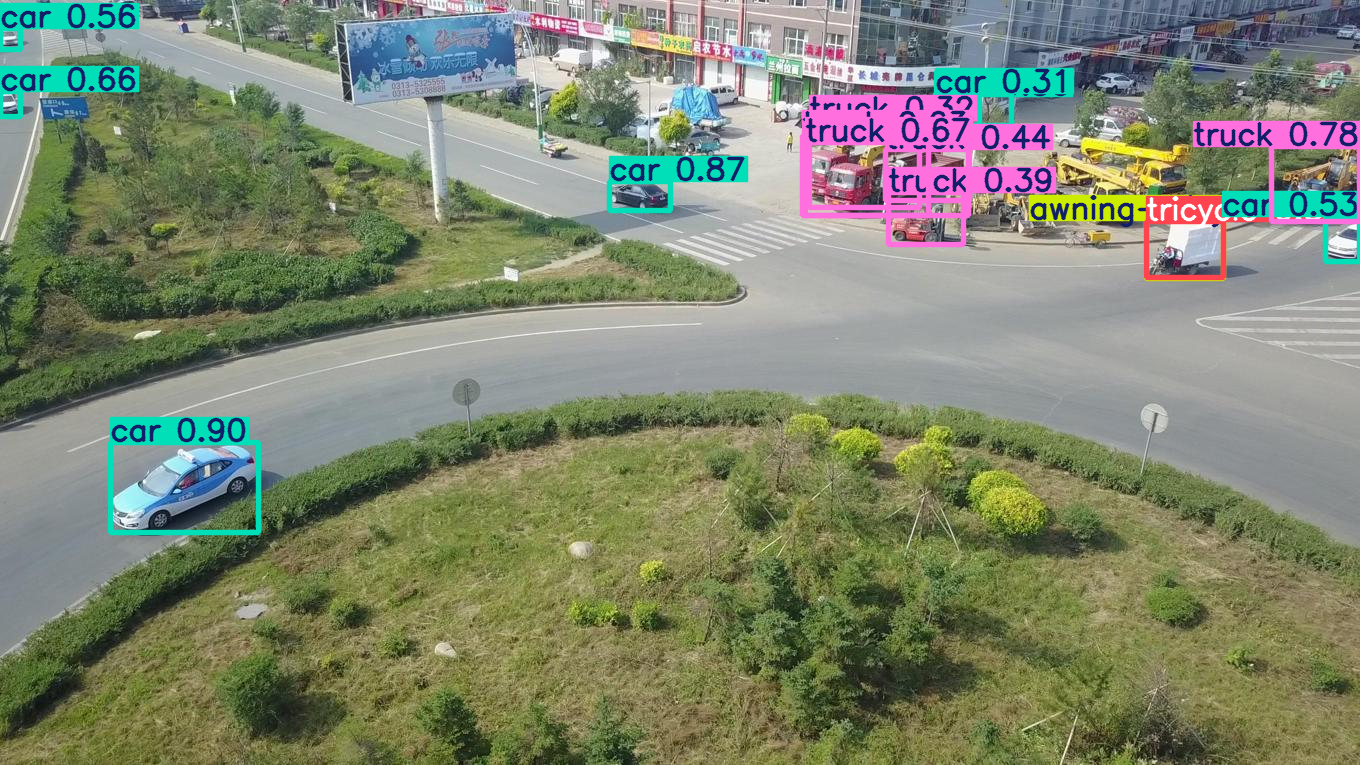

In [18]:
# Sample test image (replace with actual path)
test_img_path = os.path.join(val_img_dir, os.listdir(val_img_dir)[0]) if os.path.exists(val_img_dir) else None

if test_img_path and os.path.exists(best_weights):
    model = YOLO(best_weights)
    results = model(test_img_path)
    results[0].show()  # Display the image with detections
else:
    print("No test image or model weights found.")

# Task
Train YOLOv8 nano, small, medium, large, and extra-large models for 50 epochs each on the dataset located at "/content/drive/MyDrive/Colab Notebooks/Dataset/visDrone/VisDrone2019-DET-train", save the training results for each model in separate `results.csv` files, and suggest how to implement this process.

## Prepare for multiple training runs

### Subtask:
Define a list of YOLOv8 model variants (nano, small, medium, large, extra-large) you want to train.


**Reasoning**:
Create a list of YOLOv8 model variants as specified in the instructions.



In [19]:
model_variants = ['yolov8n.pt', 'yolov8s.pt', 'yolov8m.pt', 'yolov8l.pt', 'yolov8x.pt']
print(model_variants)

['yolov8n.pt', 'yolov8s.pt', 'yolov8m.pt', 'yolov8l.pt', 'yolov8x.pt']


## Iterate through model variants

Loop through the defined list of model variants.


In [20]:
for model_variant in model_variants:
    print(f"Processing model variant: {model_variant}")

Processing model variant: yolov8n.pt
Processing model variant: yolov8s.pt
Processing model variant: yolov8m.pt
Processing model variant: yolov8l.pt
Processing model variant: yolov8x.pt


## Load the model

Load the current YOLOv8 model variant within the loop.


In [21]:
for model_variant in model_variants:
    print(f"Processing model variant: {model_variant}")
    model = YOLO(model_variant)
    print(f"Loaded model: {model_variant}")


Processing model variant: yolov8n.pt
Loaded model: yolov8n.pt
Processing model variant: yolov8s.pt


Loaded model: yolov8s.pt
Processing model variant: yolov8m.pt


Loaded model: yolov8m.pt
Processing model variant: yolov8l.pt


Loaded model: yolov8l.pt
Processing model variant: yolov8x.pt


Loaded model: yolov8x.pt


## Train the model



In [22]:
for model_variant in model_variants:
    print(f"Processing model variant: {model_variant}")
    model = YOLO(model_variant)
    print(f"Loaded model: {model_variant}")

    # Train the model
    results = model.train(
        data=yaml_path,
        epochs=50,
        imgsz=640,
        batch=16,
        name=f'{model_variant.replace(".pt", "")}_visdrone_train'
    )
    print(f"Training complete for {model_variant}.")

Processing model variant: yolov8n.pt
Loaded model: yolov8n.pt
Ultralytics 8.3.184 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (NVIDIA L4, 22693MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Colab Notebooks/Dataset/visDrone/VisDrone.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov8n_visdrone_train, nbs=64, nms=False, opset=

train: Scanning /content/drive/MyDrive/Colab Notebooks/Dataset/visDrone/VisDrone2019-DET-train/labels.cache... 6471 images, 26 backgrounds, 0 corrupt: 100%|██████████| 6496/6496 [00:00<?, ?it/s]

train: /content/drive/MyDrive/Colab Notebooks/Dataset/visDrone/VisDrone2019-DET-train/images/0000137_02220_d_0000163.jpg: 1 duplicate labels removed
train: /content/drive/MyDrive/Colab Notebooks/Dataset/visDrone/VisDrone2019-DET-train/images/0000140_00118_d_0000002.jpg: 1 duplicate labels removed
train: /content/drive/MyDrive/Colab Notebooks/Dataset/visDrone/VisDrone2019-DET-train/images/9999945_00000_d_0000114.jpg: 1 duplicate labels removed
train: /content/drive/MyDrive/Colab Notebooks/Dataset/visDrone/VisDrone2019-DET-train/images/9999987_00000_d_0000049.jpg: 1 duplicate labels removed
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))


val: Fast image access ✅ (ping: 0.9±0.4 ms, read: 43.1±19.6 MB/s, size: 131.6 KB)


val: Scanning /content/drive/MyDrive/Colab Notebooks/Dataset/visDrone/VisDrone2019-DET-val/labels.cache... 548 images, 0 backgrounds, 0 corrupt: 100%|██████████| 548/548 [00:00<?, ?it/s]


...

      50/50      17.2G     0.9883     0.5429     0.8588        661        640: 100%|██████████| 406/406 [04:58<00:00,  1.36it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 18/18 [00:07<00:00,  2.46it/s]

                   all        548      38759       0.58       0.44      0.465      0.288



50 epochs completed in 4.345 hours.
Optimizer stripped from runs/detect/yolov8x_visdrone_train/weights/last.pt, 136.7MB
Optimizer stripped from runs/detect/yolov8x_visdrone_train/weights/best.pt, 136.7MB

Validating runs/detect/yolov8x_visdrone_train/weights/best.pt...
Ultralytics 8.3.184 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (NVIDIA L4, 22693MiB)
Model summary (fused): 112 layers, 68,133,198 parameters, 0 gradients, 257.4 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 18/18 [00:10<00:00,  1.70it/s]


                   all        548      38759       0.58      0.441      0.468      0.289
            pedestrian        520       8844      0.666      0.435      0.515       0.25
                people        482       5125      0.629      0.321      0.387      0.161
               bicycle        364       1287      0.359      0.231      0.212      0.099
                   car        515      14064      0.799      0.788      0.828      0.609
                   van        421       1975      0.556      0.501       0.51      0.367
                 truck        266        750      0.606      0.421      0.459      0.312
              tricycle        337       1045      0.502      0.377      0.378      0.212
       awning-tricycle        220        532      0.335      0.227      0.206      0.129
                   bus        131        251      0.755      0.598      0.662      0.502
                 motor        485       4886      0.593      0.507      0.523      0.249
Speed: 0.1ms preproce

In [24]:
import shutil
import os

# Define the source directory (your runs folder) and destination zip file name
source_dir = '/content/runs'
output_filename = '/content/drive/MyDrive/Colab Notebooks/Dataset/visDrone/runs_archive'

# Create a zip archive
shutil.make_archive(output_filename, 'zip', source_dir)

print(f"Created archive: {output_filename}.zip")

Created archive: /content/drive/MyDrive/Colab Notebooks/Dataset/visDrone/runs_archive.zip


In [25]:
print("Starting evaluation of trained models...")

evaluation_results = {}

for model_variant in model_variants:
    model_name = model_variant.replace(".pt", "")
    best_weights_path = f'runs/detect/{model_name}_visdrone_train/weights/best.pt'

    if os.path.exists(best_weights_path):
        print(f"\nEvaluating {model_variant} using weights from: {best_weights_path}")
        model = YOLO(best_weights_path)
        metrics = model.val(data=yaml_path) # Evaluate on the validation set
        evaluation_results[model_name] = metrics.results_dict # Store metrics
        print(f"Evaluation complete for {model_variant}.")
    else:
        print(f"\nBest weights not found for {model_variant} at {best_weights_path} - Skipping evaluation.")

print("\nEvaluation of all models complete.")
# You can now access evaluation_results dictionary to see metrics for each model
# print(evaluation_results)

Starting evaluation of trained models...

Evaluating yolov8n.pt using weights from: runs/detect/yolov8n_visdrone_train/weights/best.pt
Ultralytics 8.3.184 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (NVIDIA L4, 22693MiB)
Model summary (fused): 72 layers, 3,007,598 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.3±0.1 ms, read: 84.2±23.9 MB/s, size: 153.1 KB)


val: Scanning /content/drive/MyDrive/Colab Notebooks/Dataset/visDrone/VisDrone2019-DET-val/labels.cache... 548 images, 0 backgrounds, 0 corrupt: 100%|██████████| 548/548 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 35/35 [00:08<00:00,  4.17it/s]


                   all        548      38759      0.422      0.319      0.318      0.184
            pedestrian        520       8844      0.418      0.333      0.328      0.139
                people        482       5125      0.472      0.232      0.261     0.0943
               bicycle        364       1287      0.254      0.087     0.0702     0.0273
                   car        515      14064      0.612      0.734      0.737        0.5
                   van        421       1975      0.435      0.364      0.355      0.242
                 truck        266        750      0.469      0.297      0.309      0.201
              tricycle        337       1045      0.388      0.244      0.227      0.121
       awning-tricycle        220        532       0.26      0.148      0.123     0.0752
                   bus        131        251      0.468      0.402      0.429      0.301
                 motor        485       4886      0.444      0.347       0.34      0.138
Speed: 0.3ms preproce

val: Scanning /content/drive/MyDrive/Colab Notebooks/Dataset/visDrone/VisDrone2019-DET-val/labels.cache... 548 images, 0 backgrounds, 0 corrupt: 100%|██████████| 548/548 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 35/35 [00:07<00:00,  4.55it/s]


                   all        548      38759      0.514      0.383      0.396      0.236
            pedestrian        520       8844      0.539      0.377      0.414      0.187
                people        482       5125      0.576      0.271       0.33      0.126
               bicycle        364       1287       0.28      0.163      0.141     0.0613
                   car        515      14064      0.716      0.765      0.789      0.557
                   van        421       1975      0.517      0.451      0.449      0.314
                 truck        266        750      0.566      0.381      0.392      0.259
              tricycle        337       1045      0.414        0.3       0.29      0.163
       awning-tricycle        220        532      0.315      0.175      0.158     0.0968
                   bus        131        251      0.669      0.522      0.566      0.405
                 motor        485       4886      0.549       0.42      0.434      0.189
Speed: 0.3ms preproce

...

                   all        548      38759      0.549      0.415      0.434      0.267
            pedestrian        520       8844       0.58      0.428      0.472      0.226
                people        482       5125       0.64      0.289      0.372      0.152
               bicycle        364       1287      0.279      0.223      0.179     0.0824
                   car        515      14064      0.768      0.777      0.813      0.589
                   van        421       1975      0.505      0.487      0.478      0.345
                 truck        266        750      0.569      0.393      0.411       0.28
              tricycle        337       1045      0.489      0.334      0.337      0.193
       awning-tricycle        220        532      0.306      0.184      0.175      0.111
                   bus        131        251      0.778       0.57      0.623      0.465
                 motor        485       4886      0.575      0.463      0.485      0.227
Speed: 0.3ms preproce

val: Scanning /content/drive/MyDrive/Colab Notebooks/Dataset/visDrone/VisDrone2019-DET-val/labels.cache... 548 images, 0 backgrounds, 0 corrupt: 100%|██████████| 548/548 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 35/35 [00:10<00:00,  3.27it/s]


                   all        548      38759       0.57      0.437       0.46      0.286
            pedestrian        520       8844      0.613      0.448      0.499      0.241
                people        482       5125      0.633      0.322      0.391      0.162
               bicycle        364       1287      0.322      0.227      0.194     0.0948
                   car        515      14064      0.788      0.787      0.828      0.606
                   van        421       1975      0.514      0.518      0.501      0.359
                 truck        266        750      0.604      0.428      0.457      0.314
              tricycle        337       1045      0.485       0.38      0.372      0.216
       awning-tricycle        220        532      0.356      0.212      0.203       0.13
                   bus        131        251       0.77      0.572      0.644      0.489
                 motor        485       4886      0.618      0.476      0.517      0.247
Speed: 0.4ms preproce

val: Scanning /content/drive/MyDrive/Colab Notebooks/Dataset/visDrone/VisDrone2019-DET-val/labels.cache... 548 images, 0 backgrounds, 0 corrupt: 100%|██████████| 548/548 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 35/35 [00:12<00:00,  2.74it/s]


                   all        548      38759      0.572      0.445      0.468       0.29
            pedestrian        520       8844       0.66       0.44      0.516      0.252
                people        482       5125       0.62      0.325      0.386      0.161
               bicycle        364       1287      0.347      0.235      0.212     0.0988
                   car        515      14064      0.793      0.791      0.828       0.61
                   van        421       1975      0.547      0.504       0.51      0.367
                 truck        266        750      0.603      0.424      0.458      0.313
              tricycle        337       1045      0.496      0.382      0.379      0.212
       awning-tricycle        220        532       0.33      0.233      0.205       0.13
                   bus        131        251      0.745      0.606      0.661      0.503
                 motor        485       4886      0.581      0.514      0.522       0.25
Speed: 0.2ms preproce

In [26]:
print("--- Evaluation Results Comparison ---")
for model_name, metrics in evaluation_results.items():
    print(f"\nModel: {model_name}")
    print(f"  Precision (Box): {metrics['metrics/precision(B)']:.4f}")
    print(f"  Recall (Box): {metrics['metrics/recall(B)']:.4f}")
    print(f"  mAP50 (Box): {metrics['metrics/mAP50(B)']:.4f}")
    print(f"  mAP50-95 (Box): {metrics['metrics/mAP50-95(B)']:.4f}")
    print(f"  Fitness: {metrics['fitness']:.4f}")

--- Evaluation Results Comparison ---

Model: yolov8n
  Precision (Box): 0.4219
  Recall (Box): 0.3188
  mAP50 (Box): 0.3180
  mAP50-95 (Box): 0.1838
  Fitness: 0.1972

Model: yolov8s
  Precision (Box): 0.5140
  Recall (Box): 0.3826
  mAP50 (Box): 0.3964
  mAP50-95 (Box): 0.2358
  Fitness: 0.2519

Model: yolov8m
  Precision (Box): 0.5488
  Recall (Box): 0.4147
  mAP50 (Box): 0.4345
  mAP50-95 (Box): 0.2671
  Fitness: 0.2838

Model: yolov8l
  Precision (Box): 0.5702
  Recall (Box): 0.4371
  mAP50 (Box): 0.4605
  mAP50-95 (Box): 0.2861
  Fitness: 0.3035

Model: yolov8x
  Precision (Box): 0.5724
  Recall (Box): 0.4452
  mAP50 (Box): 0.4679
  mAP50-95 (Box): 0.2898
  Fitness: 0.3076


Displaying training and validation plots for each model variant:

--- Plots for yolov8n.pt ---
Displaying results.png:


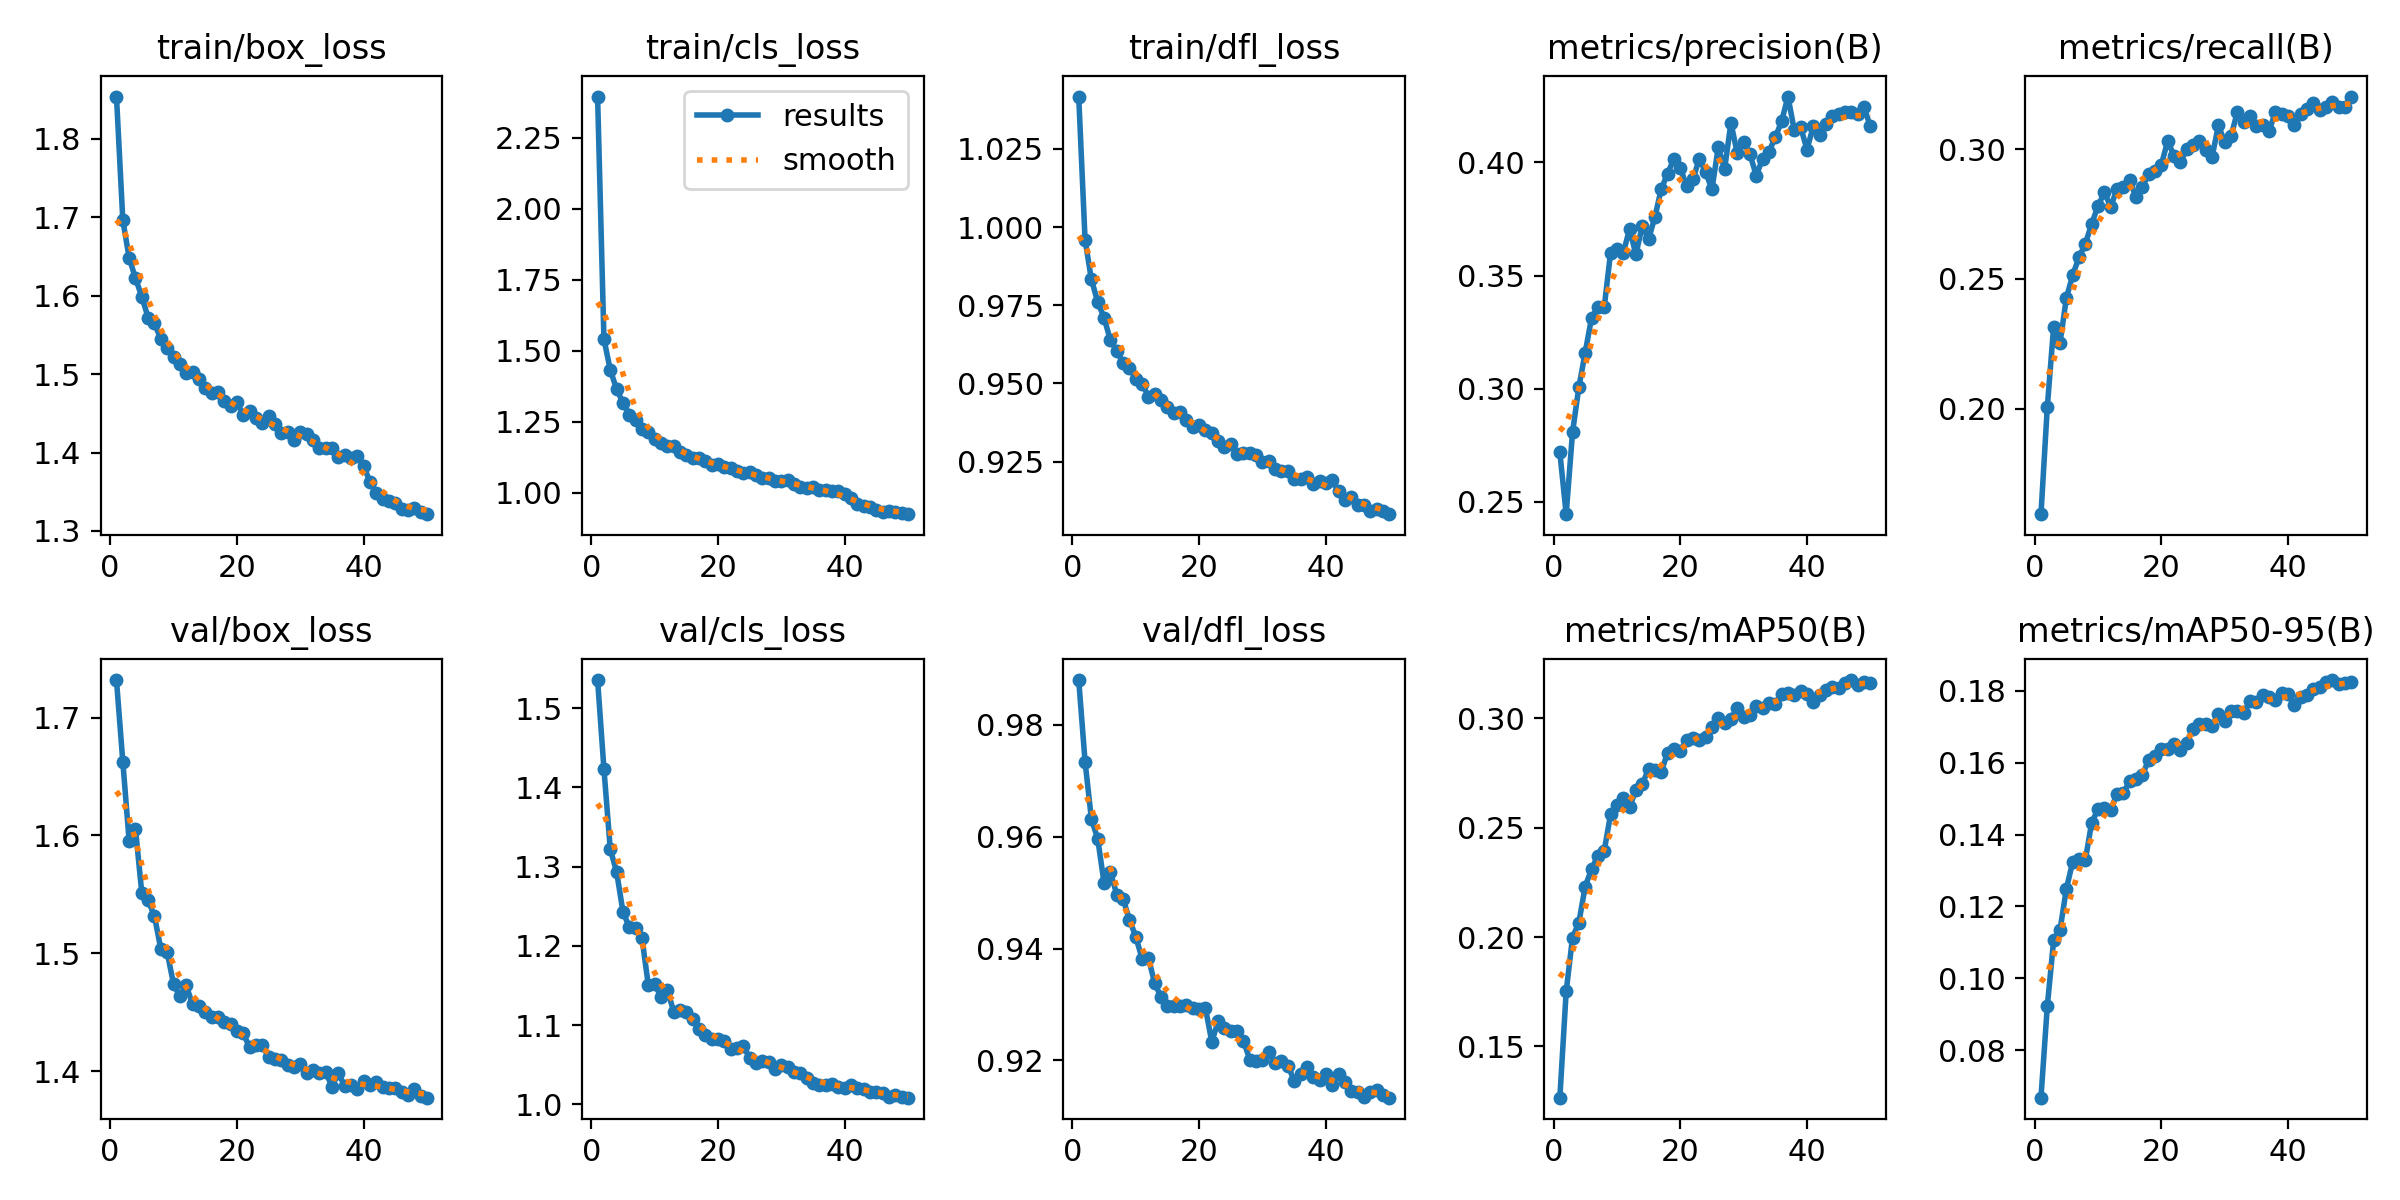

Displaying confusion_matrix.png:


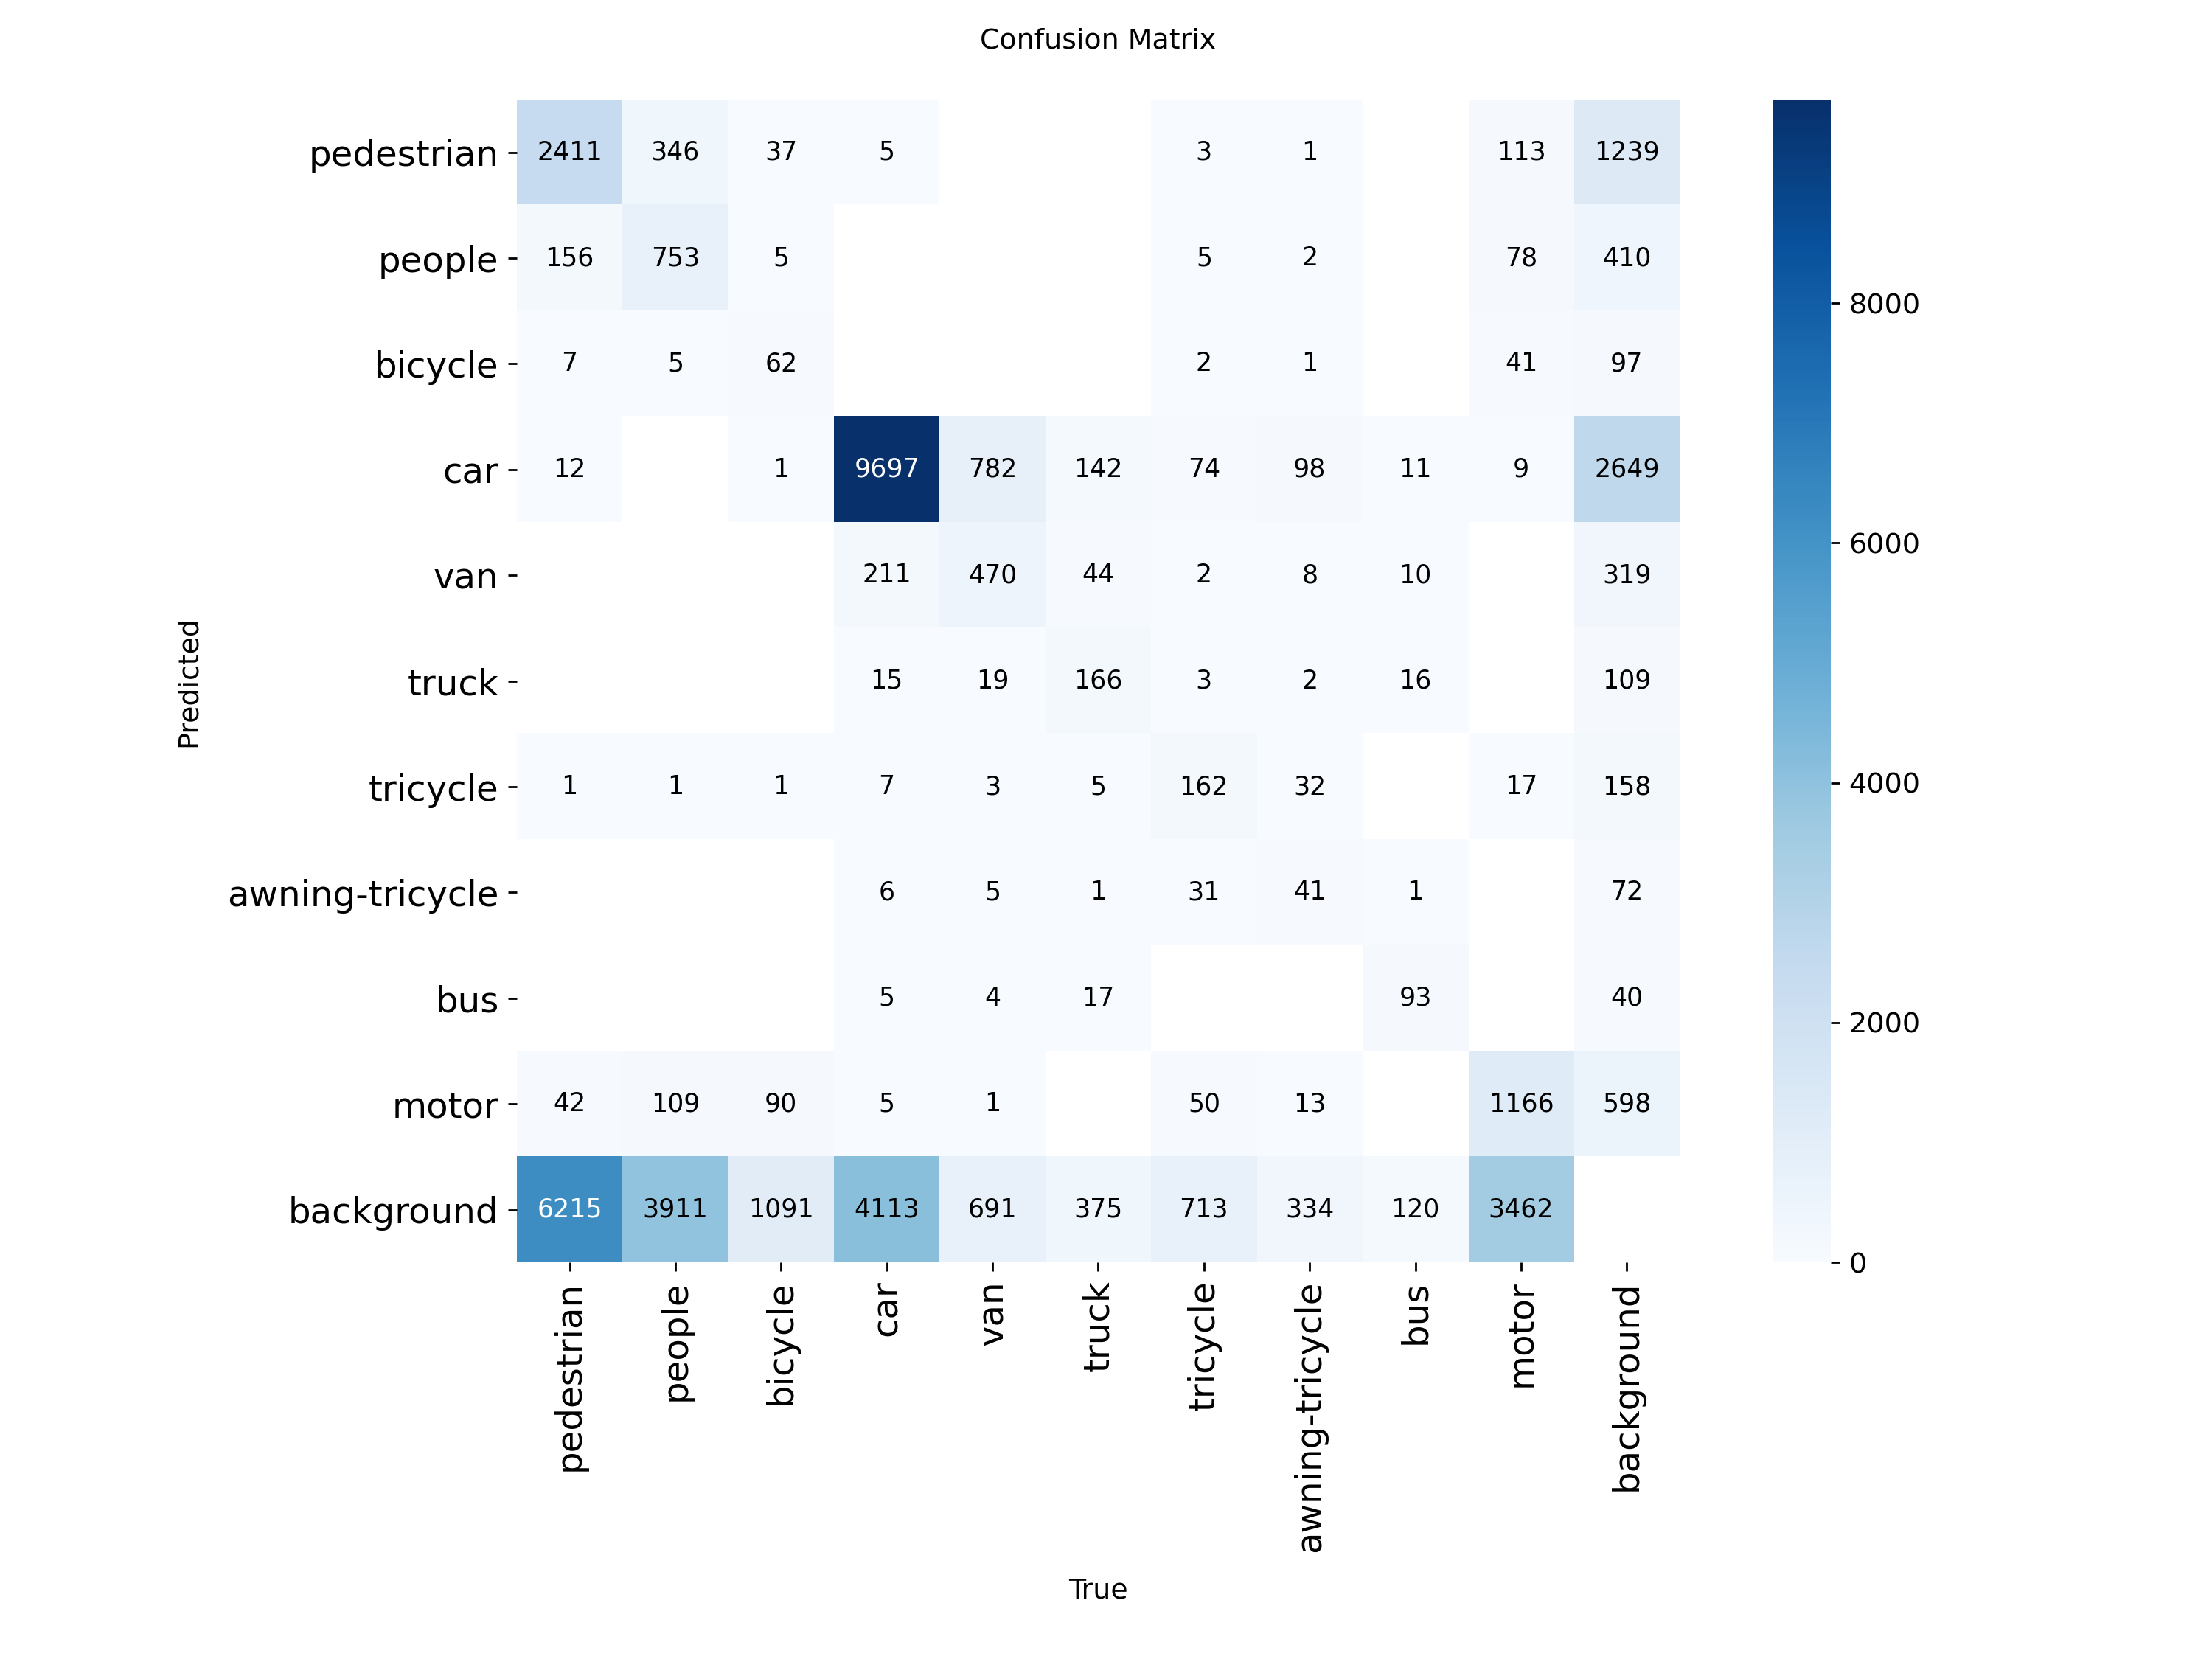


--- Plots for yolov8s.pt ---
Displaying results.png:


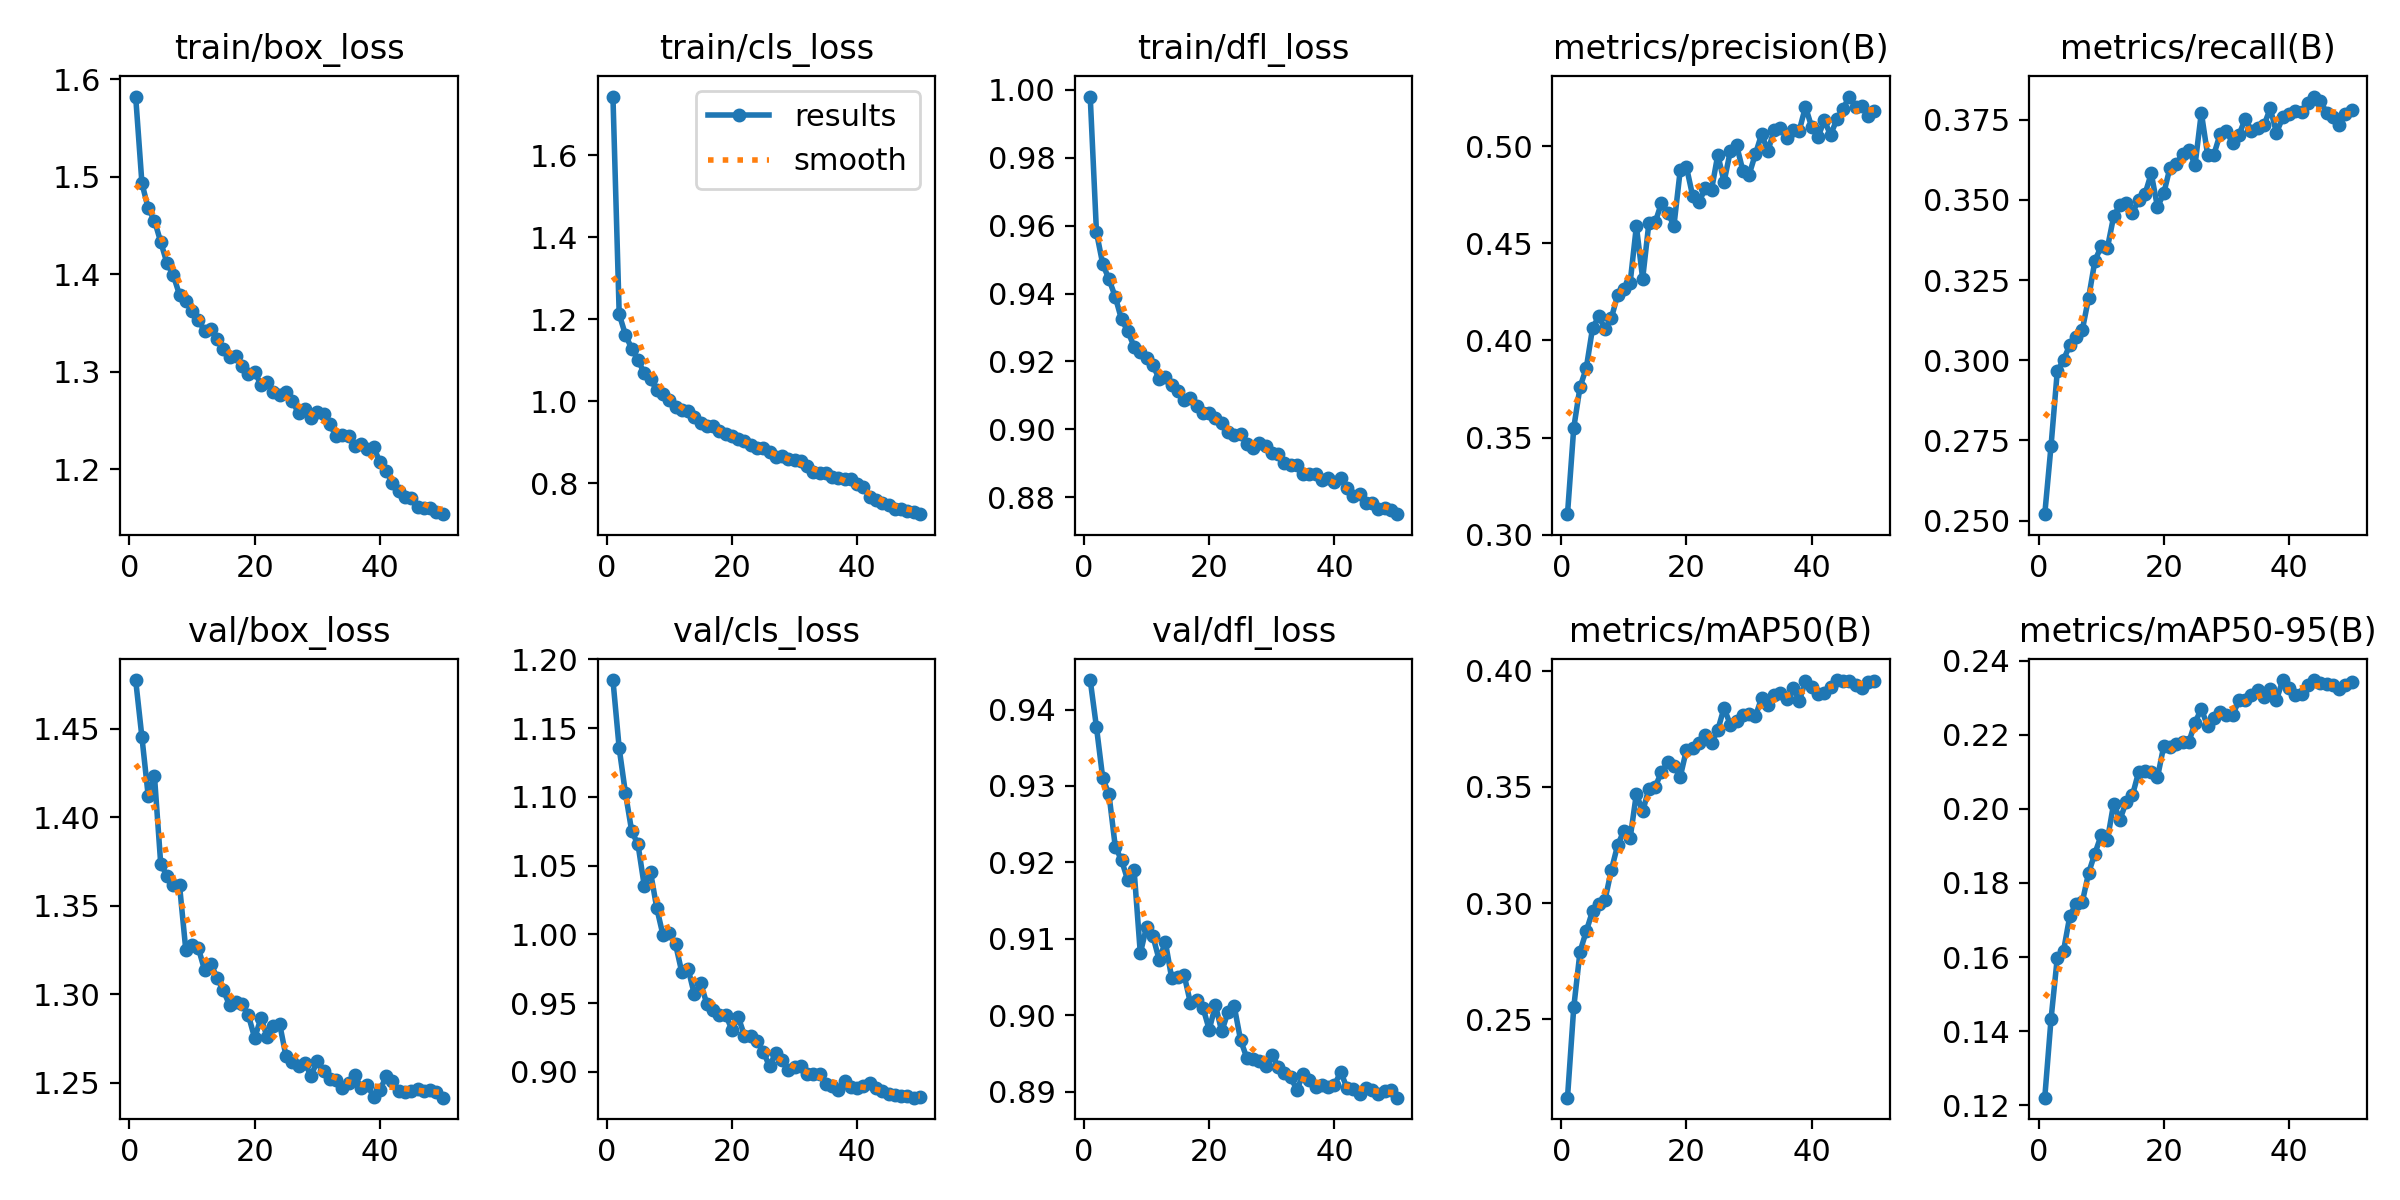

Displaying confusion_matrix.png:


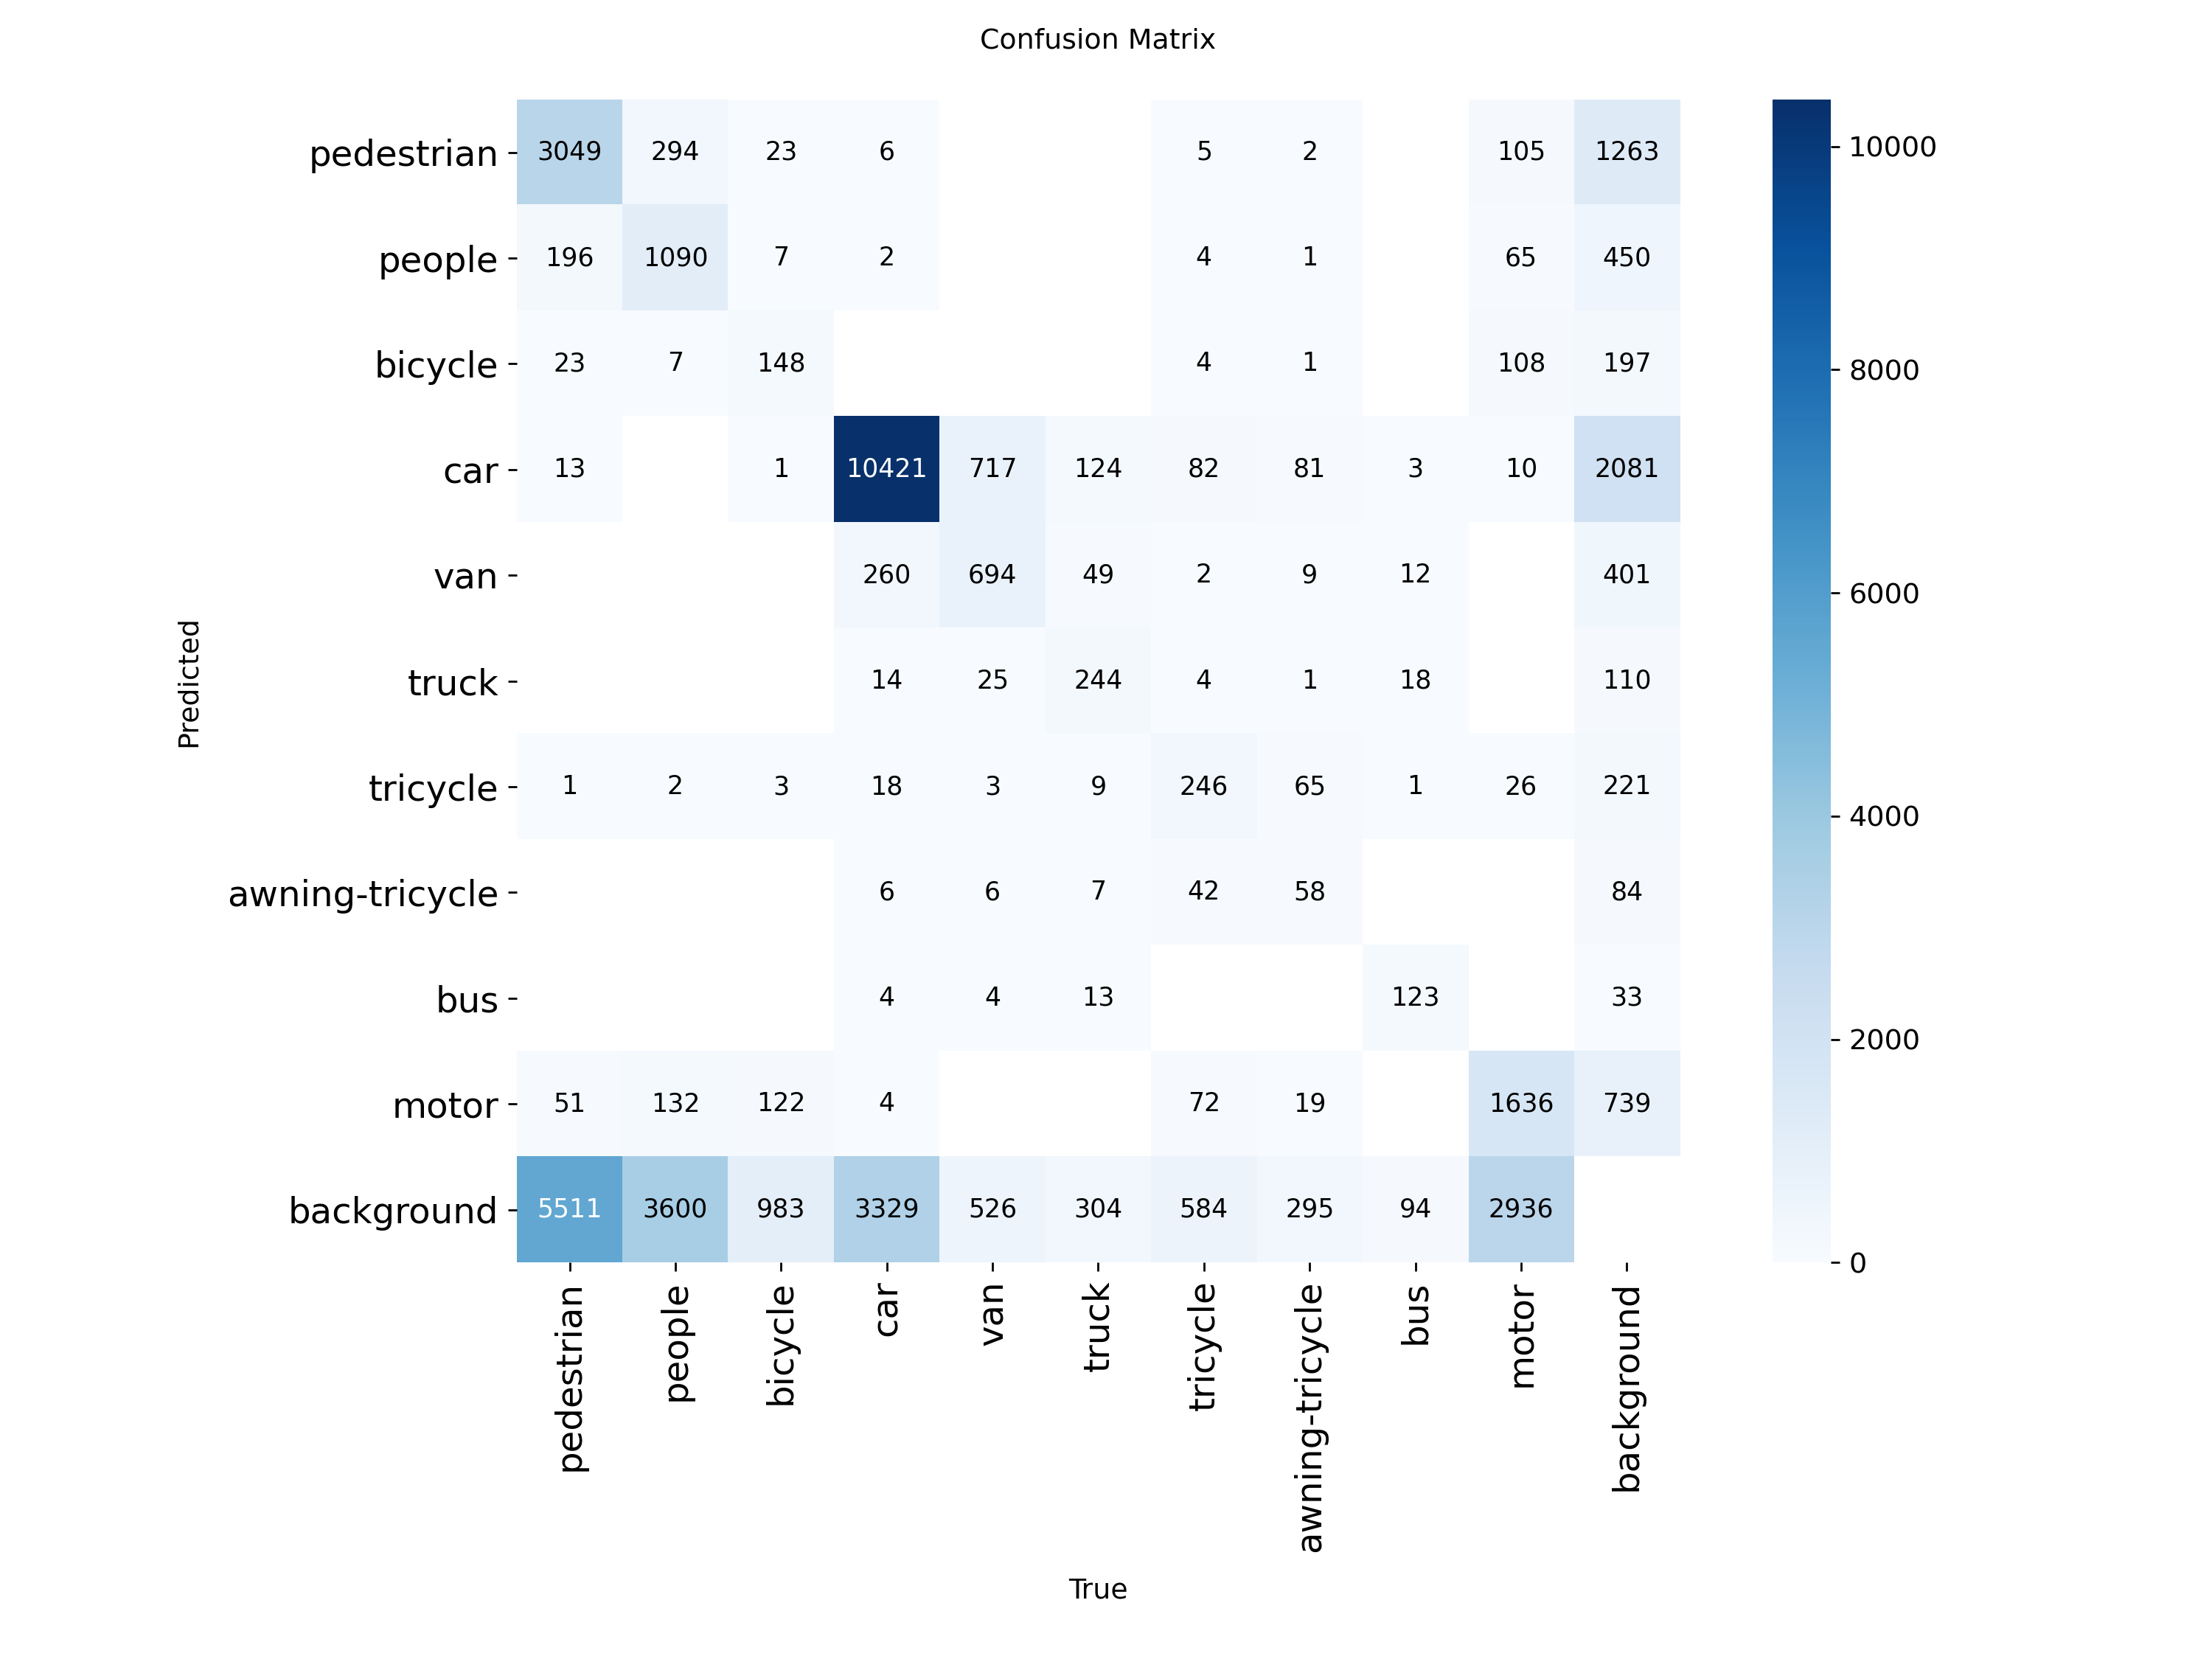


--- Plots for yolov8m.pt ---
Displaying results.png:


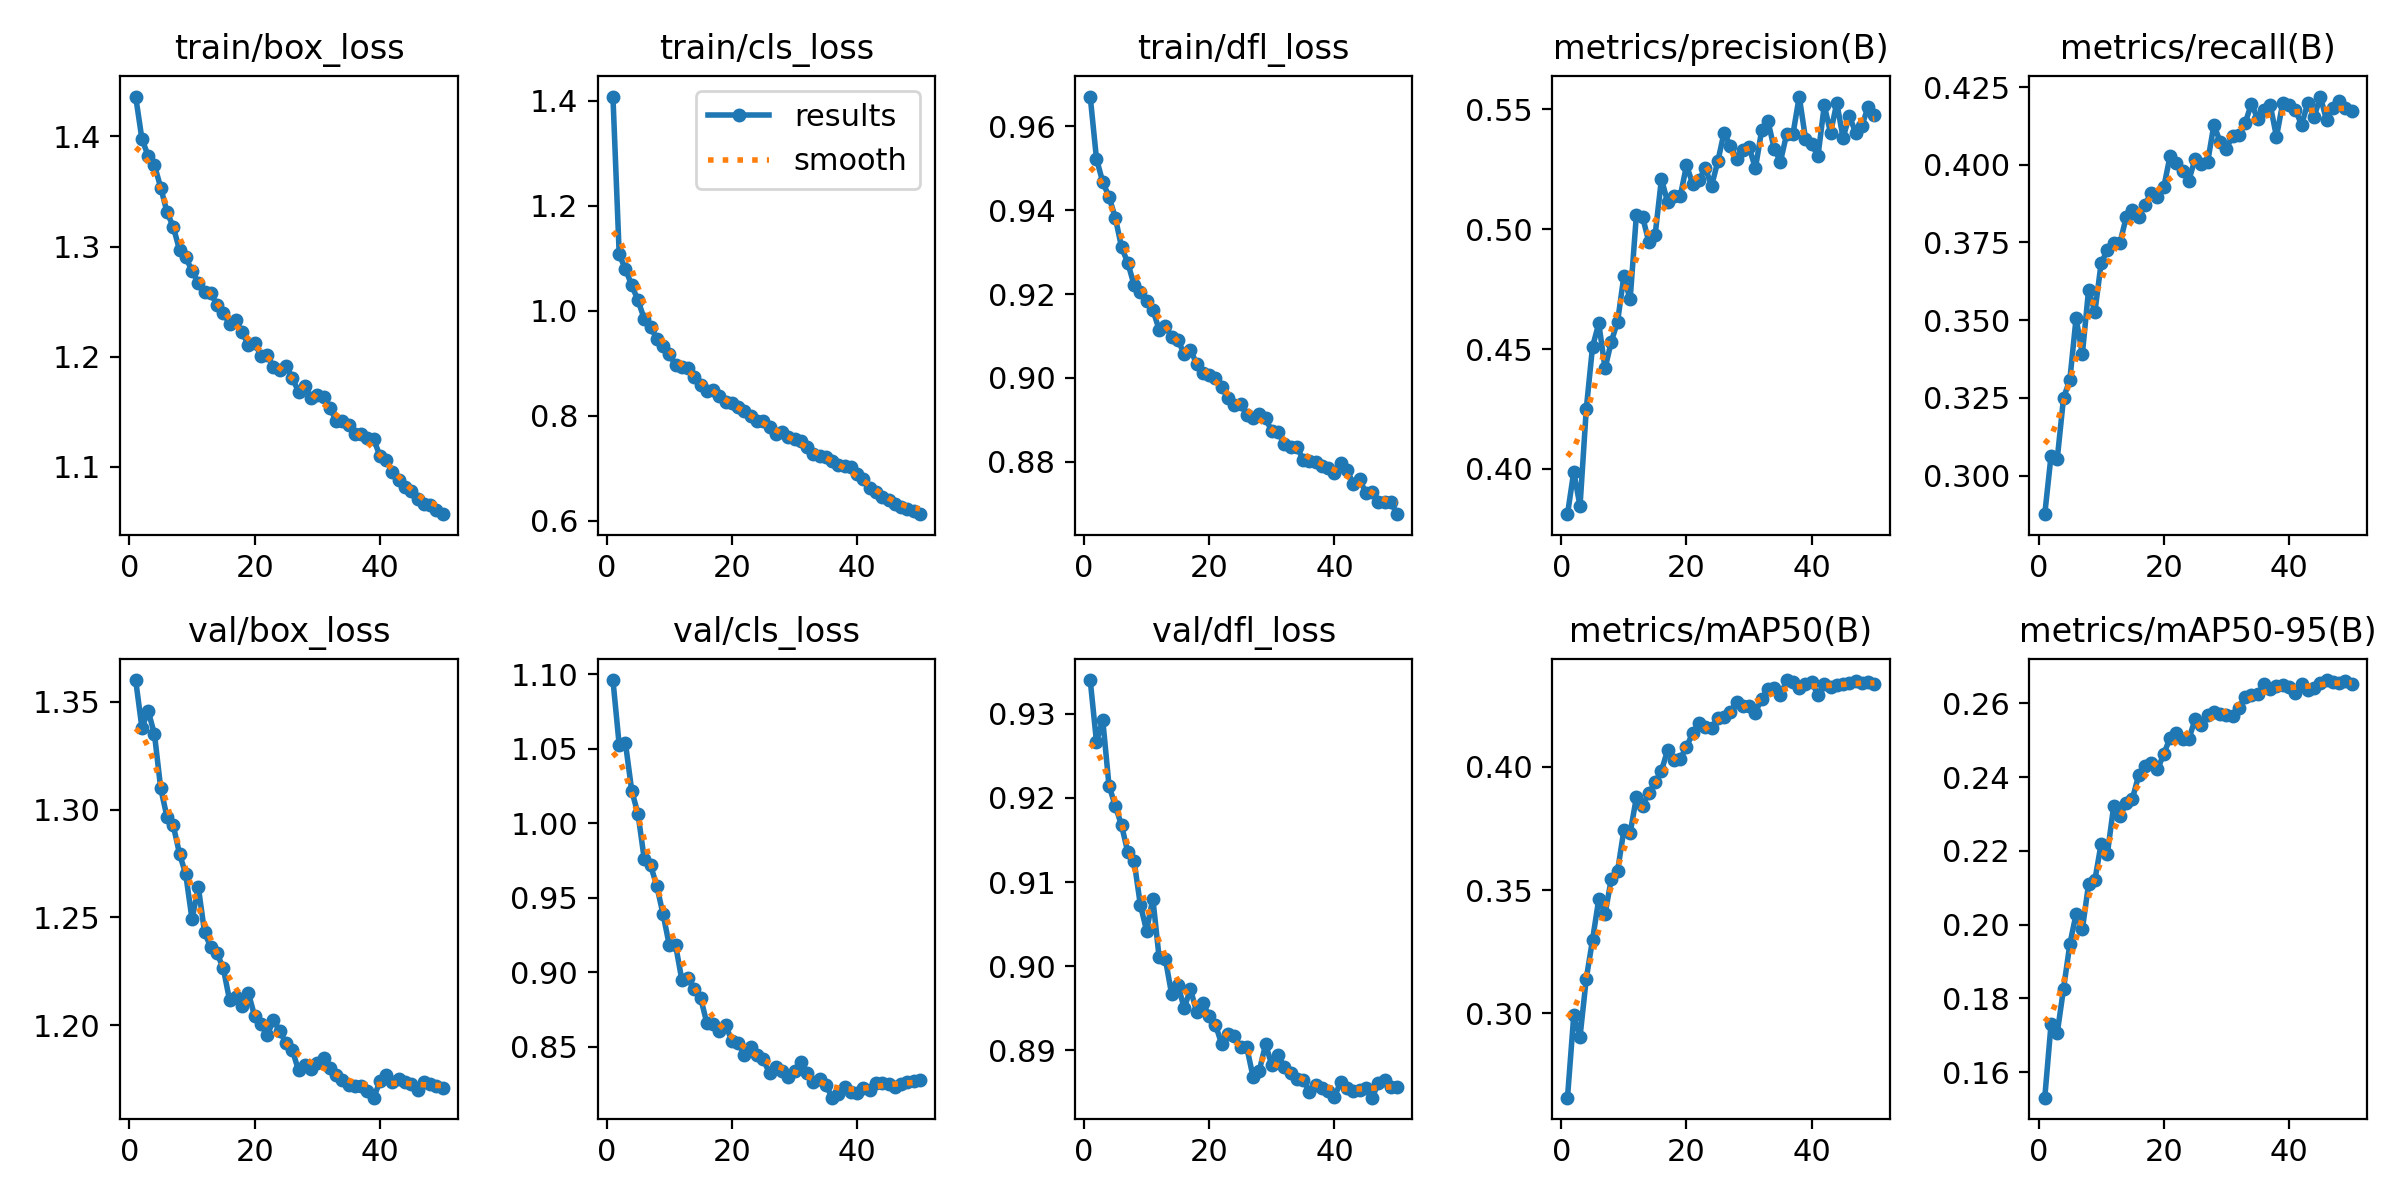

Displaying confusion_matrix.png:


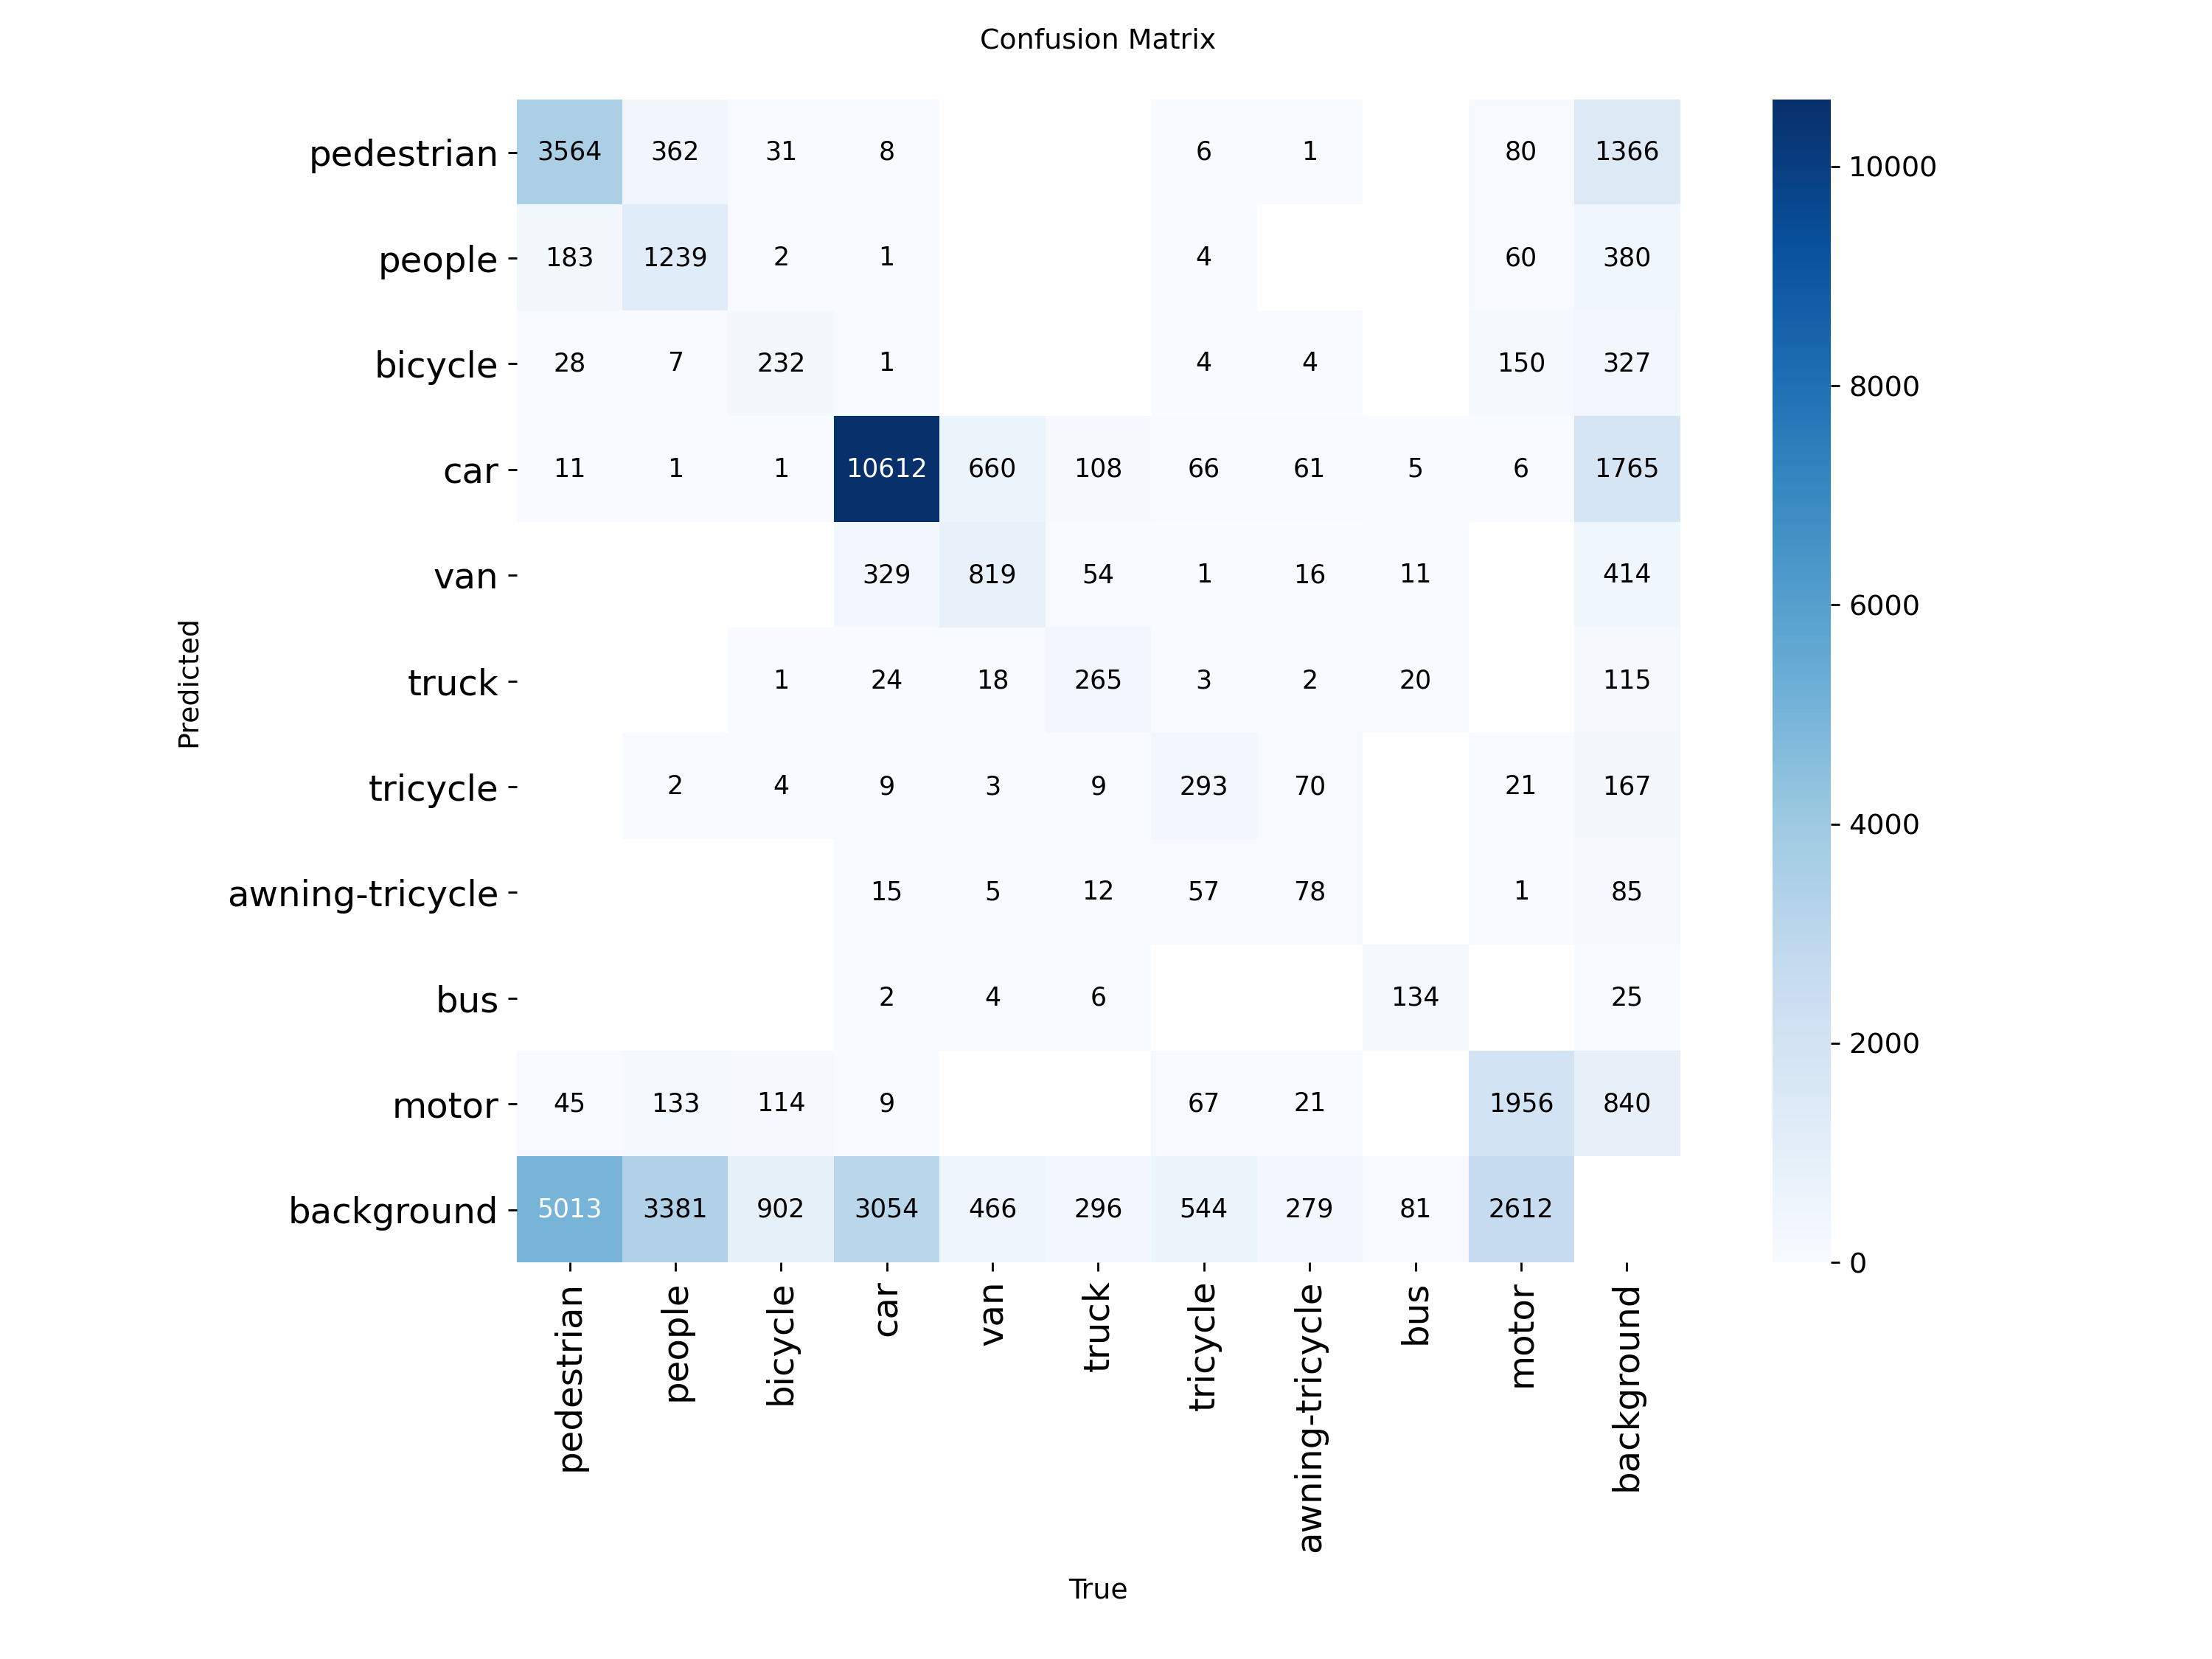


--- Plots for yolov8l.pt ---
Displaying results.png:


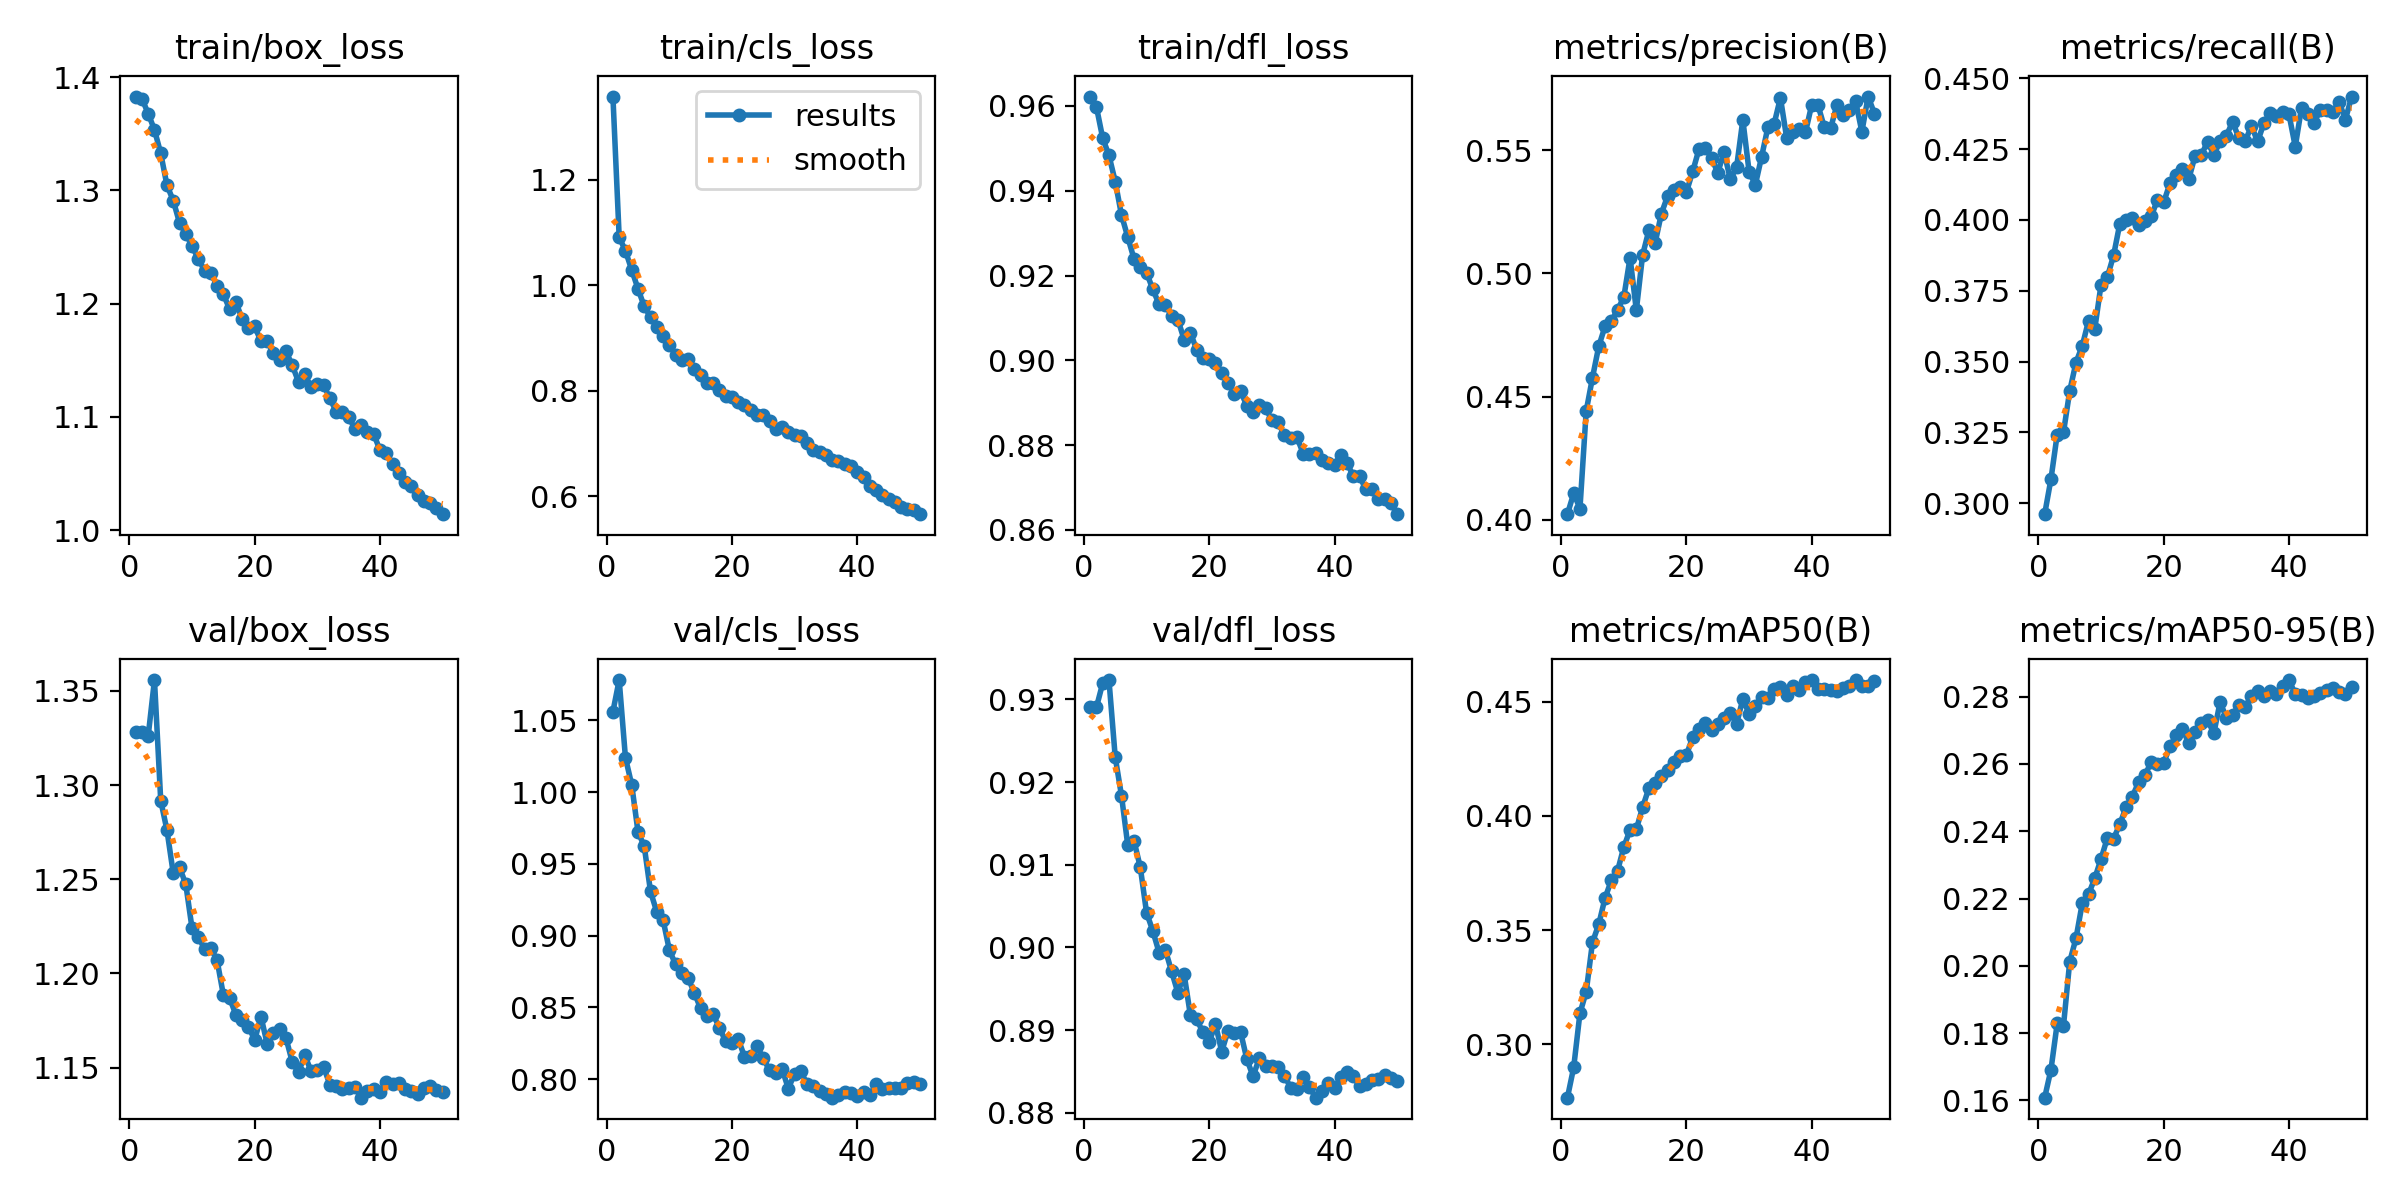

Displaying confusion_matrix.png:


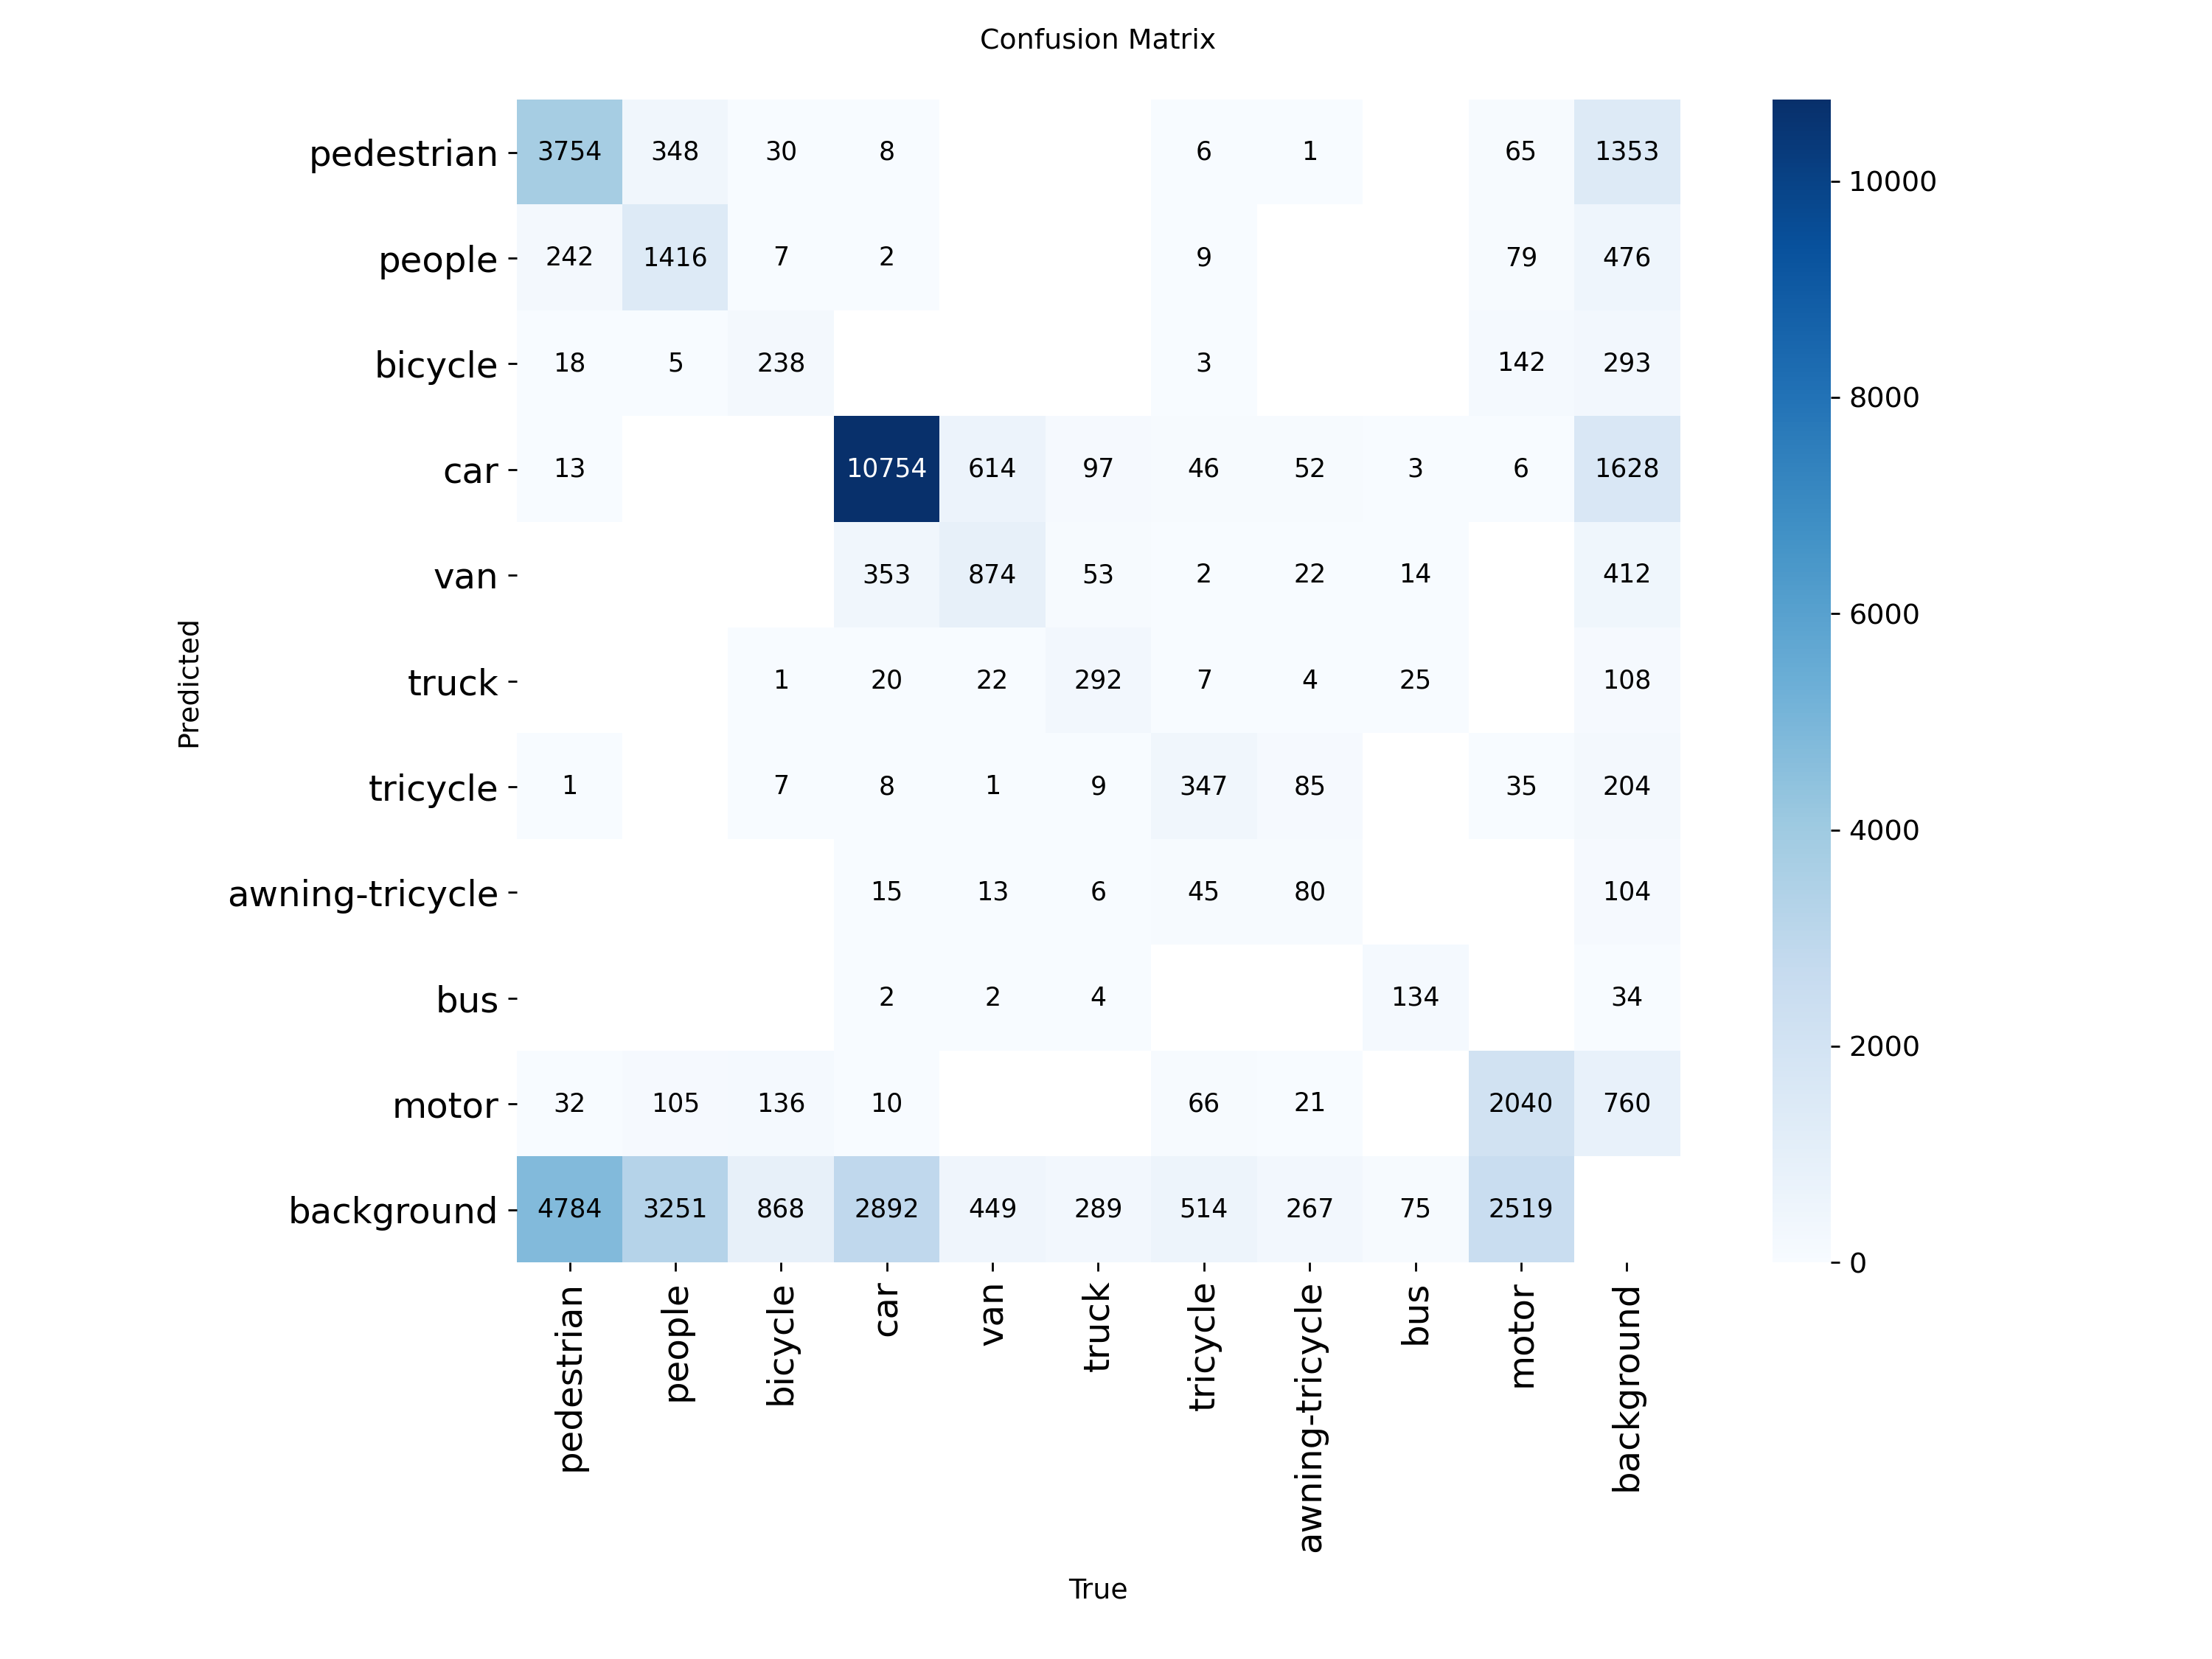


--- Plots for yolov8x.pt ---
Displaying results.png:


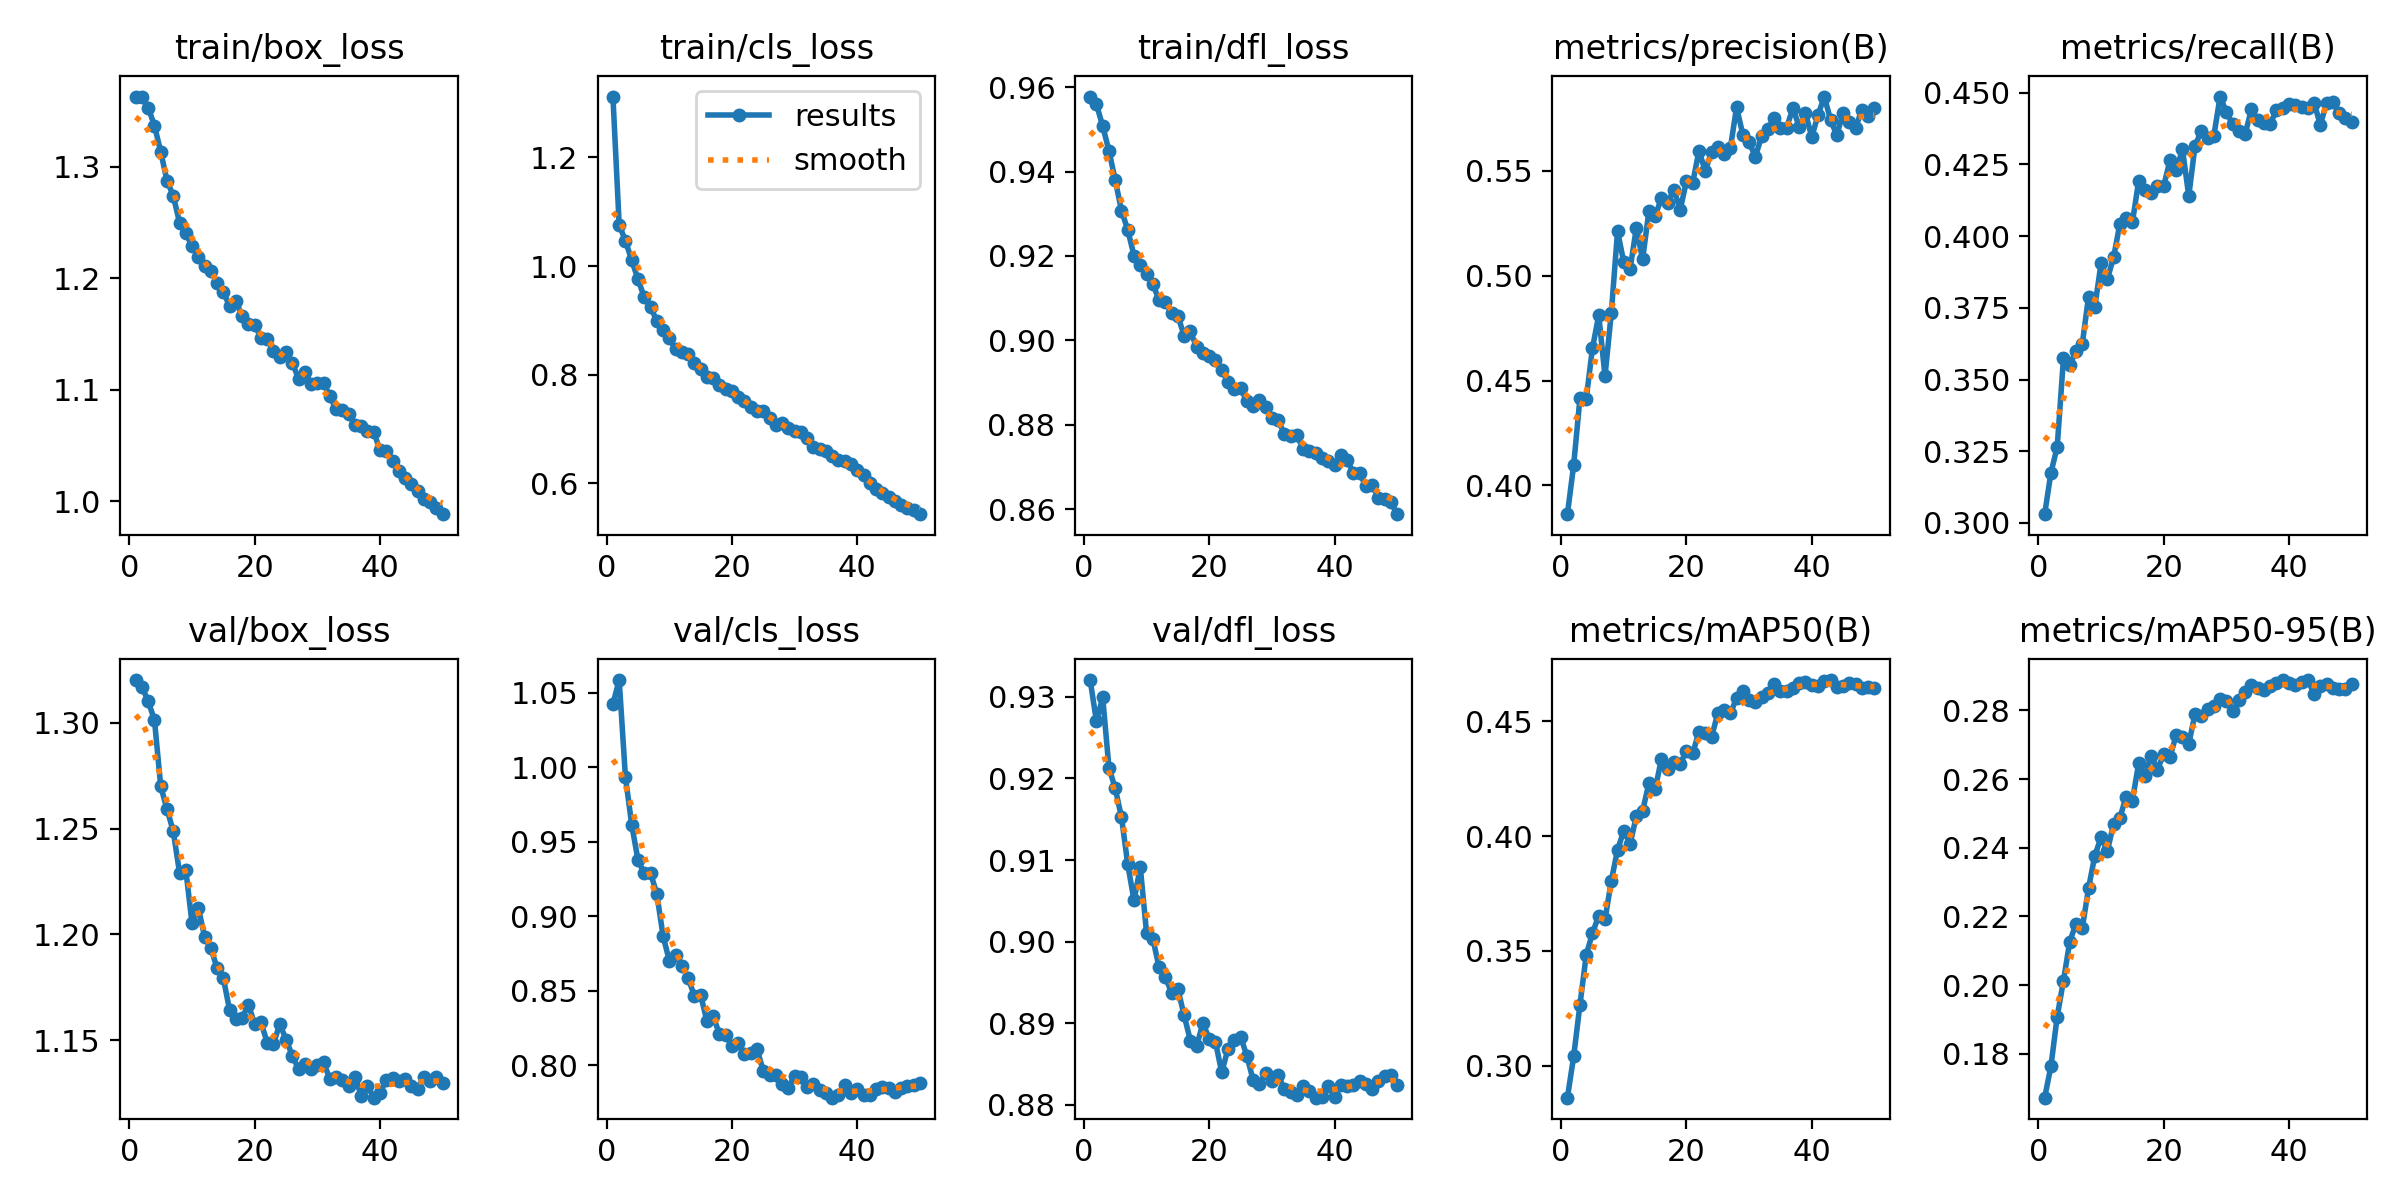

Displaying confusion_matrix.png:


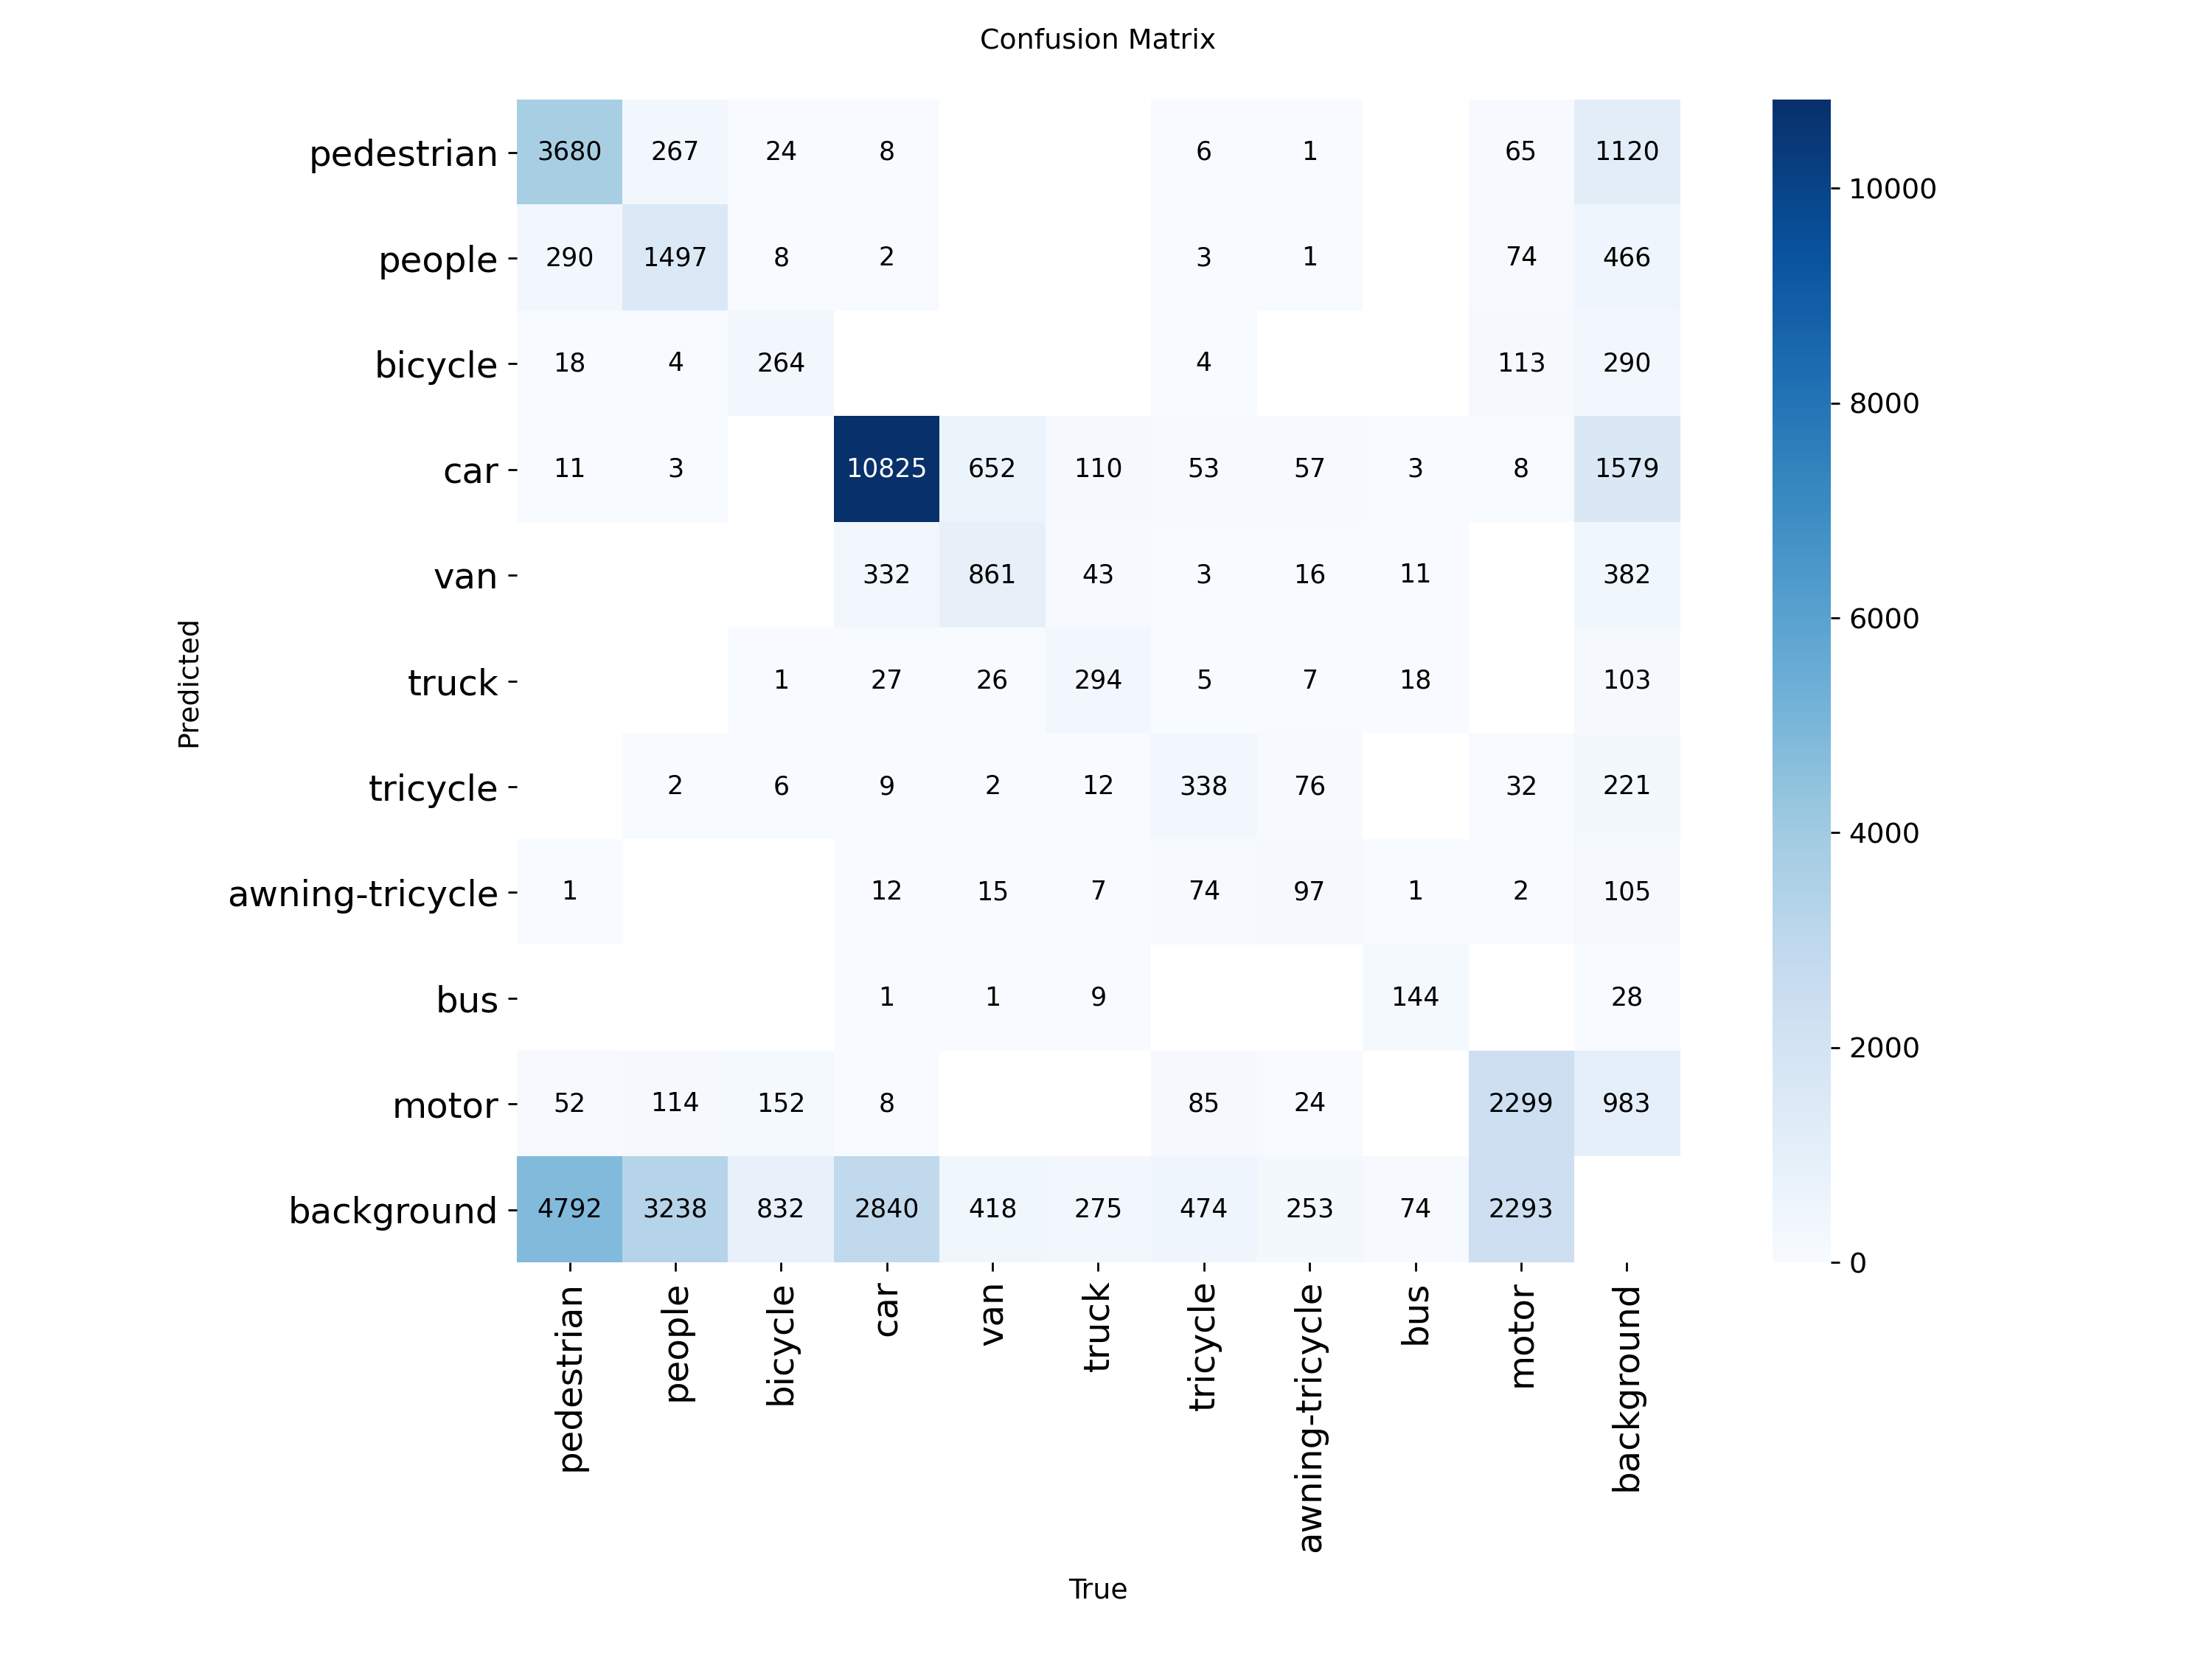


Finished displaying plots.


In [27]:
import matplotlib.pyplot as plt
import os
import IPython.display as display

print("Displaying training and validation plots for each model variant:")

for model_variant in model_variants:
    model_name = model_variant.replace(".pt", "")
    run_dir = f'runs/detect/{model_name}_visdrone_train' # Directory where results were saved

    print(f"\n--- Plots for {model_variant} ---")

    # Display results.png (contains mAP, loss, etc. over epochs)
    results_plot_path = os.path.join(run_dir, 'results.png')
    if os.path.exists(results_plot_path):
        print("Displaying results.png:")
        display.display(display.Image(results_plot_path))
    else:
        print("results.png not found.")

    # Display confusion_matrix.png
    confusion_matrix_path = os.path.join(run_dir, 'confusion_matrix.png')
    if os.path.exists(confusion_matrix_path):
        print("Displaying confusion_matrix.png:")
        display.display(display.Image(confusion_matrix_path))
    else:
        print("confusion_matrix.png not found.")

    # You can add more plots to display here if needed
    # For example, labels.jpg, confusion_matrix_normalized.png, etc.
    # See the contents of your run directories for available plots.

print("\nFinished displaying plots.")